# Calcium Imaging → Spike Inference Pipeline (`main.ipynb`)

An end-to-end, **reusable** pipeline for one-photon calcium-imaging recordings stored as
one `.npy` frame per timepoint (`ImageData_Ch<CHANNEL>_TP*.npy`). Point the **Config**
cell at your data, then run top-to-bottom. Frames are streamed one at a time (the full
stack is many GB) and every expensive step is cached under `analysis_cache/`, so re-runs
are fast.

## What this notebook does

| Step | Section | What happens |
|---|---|---|
| **Input** | 1 | Index the `.npy` frames and read the real per-frame acquisition times. |
| **Preprocess** | 2 | **2a** compares raw vs **NLM** vs **Gaussian**; **2b** you pick the method + params, then it denoises and background-subtracts every frame (cached). |
| **Visualize** | 3 | (a) **ROIs (from your label TIFF) marked** on the max-projection map; (b) **MP4** of the whole field with the **ROI mask overlaid**; (c) **dF/F trace of every ROI**. An optional **napari** cell (off by default) opens the interactive viewer. |
| **Spike inference** | 4 | Feed each ROI's dF/F to the **DS40-pretrained CASCADE** model (runs in the dedicated `CASCADE` env via `run_cascade_ds40.py`). |
| **Correlation** | 5 | ROI × ROI correlation heatmaps: **5a** dF/F, **5b** inferred spike rate, **5c** statistical comparison of the two correlation structures. |

## How to run (short version)

1. Edit only the **Config** cell — set `DATA_DIR`, `CHANNEL`, and `ROI_LABEL_PATH`.
2. Run every cell top-to-bottom. In **§2b** choose the denoise method (`"nlm"` or `"gaussian"`).
   The napari cell stays skipped unless you set `USE_NAPARI = True`.
3. For §4 (CASCADE), point `CASCADE_ENV_PYTHON` at the Python of a conda env that has
   TensorFlow/Keras + the CASCADE source under `CASCADE_ROOT`.

**Saving outputs:** by default figures and the movie are shown **inline only** (stored in the
notebook) — nothing extra is written to the project. Set `SAVE_OUTPUTS = True` in the **Output
saving** cell just below Config to also export PNGs/MP4 to `main_output/`. The §7 records
(`roi_qc.csv`, `traces.npz`, `run_manifest.yaml`) are written either way.

## Requirements

`numpy`, `matplotlib`, `scikit-image`, `scipy`, `tifffile`, `pyyaml`, `tqdm`
(+ `ffmpeg` on PATH for the MP4, and optionally `napari`/`dask` for the interactive cell).
ROIs are supplied as an integer **label TIFF** (`0` = background, `1..N` = ROIs); paint your
own in the napari cell if you don't have one yet.

## Imports

In [144]:
from __future__ import annotations

import hashlib
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
import yaml

try:
    from tqdm.auto import tqdm
except ImportError:                       # tqdm is optional -- degrade to a no-op
    def tqdm(iterable=None, **kwargs):
        return iterable

%matplotlib inline

## Config

**The only cell you normally edit.** Everything downstream reads from here.

In [145]:
# --- Data location -------------------------------------------------------------
# Frames are one .npy per timepoint, named ImageData_Ch<CHANNEL>_TP<#######>.npy
# NOTE: relative paths here resolve against the notebook's working directory, which is
# this file's folder (`main/`). A bare Path("raw") therefore means `main/raw`, which does
# not exist -- the SlideBook export lives outside the repo, so point at it absolutely.
DATA_DIR = Path("/Users/samsonho/KSL/leftDRGcut/raw")   # local SlideBook-style export
# If you CLONED this repo, put your frames in the bundled input folder and use:
#   DATA_DIR = Path("../input_data")
# Data format is always .npy (one frame per file).
CHANNEL = 0                       # which Ch<N> to analyze

CACHE_DIR = Path("analysis_cache")
CACHE_DIR.mkdir(exist_ok=True)    # working/cached files (safe to delete)

# --- ROIs: integer label TIFF (0 = background, 1..N = one ROI each) -------------
ROI_LABEL_PATH = Path("/Users/samsonho/KSL/leftDRGcut/_labels/Debi_DRG_ROI.tiff")
# If you CLONED this repo, store your ROI '.tiff' mask files under /main/labels/
# (i.e. /main/labels/{your ROI '.tiff' mask files here}) and point this there:
#   ROI_LABEL_PATH = Path("/main/labels/<your_ROI_mask>.tiff")

# --- dF/F: rolling low-percentile baseline --------------------------------------
BASELINE_PERCENTILE = 10  # ~inactive baseline level
BASELINE_WINDOW_S = 15    # rolling window length (s)

# --- CASCADE DS40 spike inference (section 4) -----------------------------------
CASCADE_ENV_PYTHON = Path("/Users/samsonho/exit()/envs/CASCADE/bin/python")  # env WITH TensorFlow
CASCADE_ROOT = Path("/Users/samsonho/KSL/leftDRGcut/cascade_runtime")  # cascade2p/ + Pretrained_models/ (kept outside this repo)
CASCADE_BRIDGE = Path("../data_pre-n-vis/run_cascade_ds40.py")        # subprocess bridge shipped with this repo
CASCADE_MODEL_NAME = "Spinal_cord_excitatory_30Hz_smoothing50ms"

# --- Acquisition metadata (needed by sections 3f, 7, 10) ------------------------
MODALITY = "widefield-1p"  # widefield camera acquisition: NO optical sectioning (see 3f)
PIXEL_SIZE_UM = None       # None -> read mMicronPerPixel from <DATA_DIR>/ImageRecord.yaml
EXPOSURE_MS = None         # None -> read mExposureTime  (widefield: exposure, not laser power)
OBJECTIVE_MAG = None       # None -> read mActualMagnification
INDICATOR = None           # e.g. "GCaMP6s" -- steps that genuinely need it raise if None

# --- Hardening switches (sections 1b / 3f) --------------------------------------
USE_MOTION_CORRECTION = True
MOTION_MAX_SHIFT_FRAC = 0.5    # censor a frame if |shift| > this x median ROI radius
TRACE_DENOISE = "none"         # 3f extracts traces from UNBLURRED frames (see 3f markdown)
BACKGROUND_MODE = "none"       # "none" | "field" | "scalar_pct" (the legacy scalar)
BACKGROUND_FIELD_SIGMA = 64    # px, background-field width when BACKGROUND_MODE="field"
NEUROPIL_R_IN_UM, NEUROPIL_R_OUT_UM = 3.0, 12.0
NEUROPIL_ALPHA_MODE = "estimated"   # "estimated" (per-ROI, from the data) or "fixed"
NEUROPIL_ALPHA = 1.0           # used when mode="fixed". 1.0 is the widefield expectation
                               # (no sectioning -> near-full background contamination);
                               # the familiar 0.7 is a 2-photon convention (Chen 2013).
N_BLANK_ROIS = 3               # soma-free negative-control regions
LEGACY_PIPELINE = False        # True -> section 5 uses the old 3d traces, for diffing

# --- Interactive napari viewer: OFF by default (see the napari cell in section 3) --
USE_NAPARI = False

# NOTE: the denoise method + its parameters live in section 2 (cell 2b) so you can
# compare NLM vs Gaussian in 2a before committing to one.

### Cache keys

Every cached artifact is keyed by a digest of the parameters that produced it. Previously
`preprocessed_*` was keyed only by method and the ROI traces only by method + ROI *count*,
so changing `GAUSSIAN_SIGMA` or repainting a mask with the same number of ROIs silently
reused a stale cache. Same md5 pattern as the CASCADE cache in §4.


In [146]:
def param_digest(*parts, n=10) -> str:
    """Short md5 over any mix of scalars, strings, paths and arrays."""
    h = hashlib.md5()
    for p in parts:
        h.update(np.ascontiguousarray(p).tobytes() if isinstance(p, np.ndarray) else repr(p).encode())
    return h.hexdigest()[:n]


## Output saving (optional)

Choose whether to **also** write figures (PNG) and the movie (MP4) to disk. By default
`SAVE_OUTPUTS = False`, so everything is only shown inline and lives inside the notebook —
nothing is written to `main_output/`. Flip it to `True` to additionally export to
`OUTPUT_DIR` (`main_output/`, which will be `/main/main_output` in a cloned repo).

In [147]:
# By default, figures and the movie are only shown inline (and stored in this
# notebook) -- nothing extra is written to the project. Set SAVE_OUTPUTS = True to
# ALSO save every figure (PNG) and the movie (MP4) into OUTPUT_DIR.
SAVE_OUTPUTS = False
OUTPUT_DIR = Path("main_output")   # in a cloned repo this path will be /main/main_output

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Write fig to OUTPUT_DIR/<name>.png -- but only when SAVE_OUTPUTS is True."""
    if SAVE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", dpi=200, bbox_inches="tight")


print(
    f"SAVE_OUTPUTS = {SAVE_OUTPUTS} -> "
    + (f"also writing PNG/MP4 to {OUTPUT_DIR}/" if SAVE_OUTPUTS
       else "figures/movie shown inline only (nothing written to main_output)")
)

SAVE_OUTPUTS = False -> figures/movie shown inline only (nothing written to main_output)


## 1. Input — index the `.npy` frames and the time axis

Builds a timepoint-ordered list of frame paths and reads the real acquisition times from
`ElapsedTimes.yaml` (falling back to a nominal 10 Hz axis if it is missing or mismatched).
Nothing is loaded into RAM yet — `load_frame(i)` reads a single frame on demand.

In [148]:
_TP_RE = re.compile(r"_TP(\d+)\.npy$")


def build_index(data_dir: Path = DATA_DIR, channel: int = CHANNEL) -> list[Path]:
    files = [p for p in data_dir.glob(f"ImageData_Ch{channel}_TP*.npy") if _TP_RE.search(p.name)]
    if not files:
        raise FileNotFoundError(
            f"No frames matched {data_dir}/ImageData_Ch{channel}_TP*.npy -- "
            "check DATA_DIR and CHANNEL in the Config cell."
        )
    return sorted(files, key=lambda p: int(_TP_RE.search(p.name).group(1)))


def load_time_axis(n_frames: int, data_dir: Path = DATA_DIR) -> np.ndarray:
    """Per-frame acquisition time in seconds (starts at 0)."""
    yaml_path = data_dir / "ElapsedTimes.yaml"
    if yaml_path.is_file():
        raw = yaml.safe_load(open(yaml_path))["theElapsedTimes"][1:]  # [0] is a count, not a time
        t = np.asarray(raw, dtype=float)[:n_frames] / 1000.0
        if len(t) == n_frames:
            return t - t[0]
        print(f"! ElapsedTimes has {len(raw)} entries but {n_frames} frames; using nominal 10 Hz.")
    return np.arange(n_frames, dtype=float) / 10.0


def read_slidebook(key: str, data_dir: Path = DATA_DIR, name: str = "ImageRecord.yaml"):
    """One scalar from a SlideBook YAML, by line scan -- these files also hold a huge
    thumbnail array that is pointless to parse."""
    record = data_dir / name
    if record.is_file():
        for line in open(record):
            if f"{key}:" in line:
                return float(line.split(":")[1])
    return None


def load_pixel_size(data_dir: Path = DATA_DIR) -> float | None:
    return float(PIXEL_SIZE_UM) if PIXEL_SIZE_UM is not None else read_slidebook("mMicronPerPixel", data_dir)


def load_frame(i: int) -> np.ndarray:
    """One raw (H, W) frame, untouched."""
    return np.load(image_files[i]).squeeze(axis=0)


image_files = build_index()
n_frames = len(image_files)
times_s = load_time_axis(n_frames)
frame_shape = load_frame(0).shape
fps_native = 1.0 / np.median(np.diff(times_s))
pixel_um = load_pixel_size()
exposure_ms = EXPOSURE_MS if EXPOSURE_MS is not None else read_slidebook("mExposureTime", DATA_DIR, "ChannelRecord.yaml")
objective_mag = OBJECTIVE_MAG if OBJECTIVE_MAG is not None else read_slidebook("mActualMagnification")
print(f"{n_frames} frames of {frame_shape} over {times_s[-1]:.1f} s (~{fps_native:.1f} Hz)")
print(f"{MODALITY} | pixel {pixel_um if pixel_um is None else f'{pixel_um:.4f} um/px'} | "
      f"exposure {exposure_ms} ms | {objective_mag}x | indicator: {INDICATOR}")

3220 frames of (1024, 1376) over 322.2 s (~10.0 Hz)
widefield-1p | pixel 0.8802 um/px | exposure 100.0 ms | 16.0x | indicator: None


## 1b. Motion correction (rigid)

CLAUDE.md §3 puts motion correction first, and flags the DRG prep as especially prone to
pulsatile/respiratory artifact. Nothing upstream of this notebook did it. Field-wide motion
adds the *same* signal to every ROI, so it inflates the §5 correlation directly — this is
the single largest threat to that result.

Each frame is aligned to a template built from the ~100 quietest frames, by rigid
sub-pixel phase cross-correlation. Non-rigid (NoRMCorre/suite2p) is deliberately **not**
the starting point: use it only if the QC below shows structured residual motion.

**How the shifts get applied.** ROIs here are 39–97 px across, so sub-pixel interpolation is
irrelevant to a mean over an ROI while it *does* blur — working against §3f, which exists to
keep blur out of the traces. So §3f shifts the **mask pixel indices** by the rounded shift
rather than interpolating the image. The sub-pixel shifts are what get reported in QC below.

The ROI label TIFF is static: it is applied to a *stabilised* stack, which is the point.
Masks are not tracked per frame.

**What this cannot catch, and it matters more in widefield.** Rigid registration measures
*lateral* displacement only. With no optical sectioning, axial (focus/z) drift and lamp
fluctuation change brightness across the entire field while producing **no lateral shift at
all** — they are invisible here by construction. So a clean result in this section is not a
clean bill of health: it narrows the candidates rather than clearing them. The soma-free blank
ROIs in §3f are the control that can see a field-wide term, and §5d/§8 are where it is
quantified.

`frame_valid` (frames whose motion is too large to trust) is computed in §3f, where the ROI
radius that sets the threshold is known. The per-ROI motion-confound test is §3g.


In [149]:
from skimage.registration import phase_cross_correlation

MOTION_TEMPLATE_N = 100      # frames averaged into the registration template
MOTION_SAMPLE_STEP = 8       # subsample used to find the quietest frames
MOTION_CACHE = CACHE_DIR / (f"motion_ch{CHANNEL}_"
                            f"{param_digest(n_frames, MOTION_TEMPLATE_N, MOTION_SAMPLE_STEP)}.npz")


def _mean_of(indices):
    acc = np.zeros(frame_shape, dtype=np.float64)
    for i in indices:
        acc += load_frame(int(i))
    return (acc / len(indices)).astype(np.float32)


def _shifts_against(template, indices, desc):
    out = np.empty((len(indices), 2), dtype=np.float64)
    for k, i in enumerate(tqdm(indices, desc=desc)):
        out[k] = phase_cross_correlation(template, load_frame(int(i)).astype(np.float32),
                                         upsample_factor=10)[0]
    return out


def compute_motion(overwrite=False):
    """(dy, dx) per frame that aligns it to a template of the quietest frames."""
    if MOTION_CACHE.exists() and not overwrite:
        with np.load(MOTION_CACHE) as d:
            return d["shifts"], d["template"]
    sample = np.arange(0, n_frames, MOTION_SAMPLE_STEP)
    rough = _shifts_against(_mean_of(sample), sample, "template pass")
    quiet = np.sort(sample[np.argsort(np.hypot(*rough.T))[:MOTION_TEMPLATE_N]])
    template = _mean_of(quiet)
    shifts = _shifts_against(template, np.arange(n_frames), "registering")
    np.savez_compressed(MOTION_CACHE, shifts=shifts, template=template, quiet=quiet)
    return shifts, template


if USE_MOTION_CORRECTION:
    shifts, mc_template = compute_motion()
else:                                   # keep the downstream code paths identical
    shifts, mc_template = np.zeros((n_frames, 2)), _mean_of(np.arange(0, n_frames, 50))
    print("motion correction DISABLED (USE_MOTION_CORRECTION = False)")

shift_mag = np.hypot(*shifts.T)
print(f"|shift|: median {np.median(shift_mag):.2f} px, 95th pct {np.percentile(shift_mag, 95):.2f} px, "
      f"max {shift_mag.max():.2f} px"
      + (f" ({np.median(shift_mag) * pixel_um:.2f} um median)" if pixel_um else ""))


|shift|: median 0.00 px, 95th pct 0.00 px, max 0.10 px (0.00 um median)


motion QC:   0%|          | 0/202 [00:00<?, ?it/s]

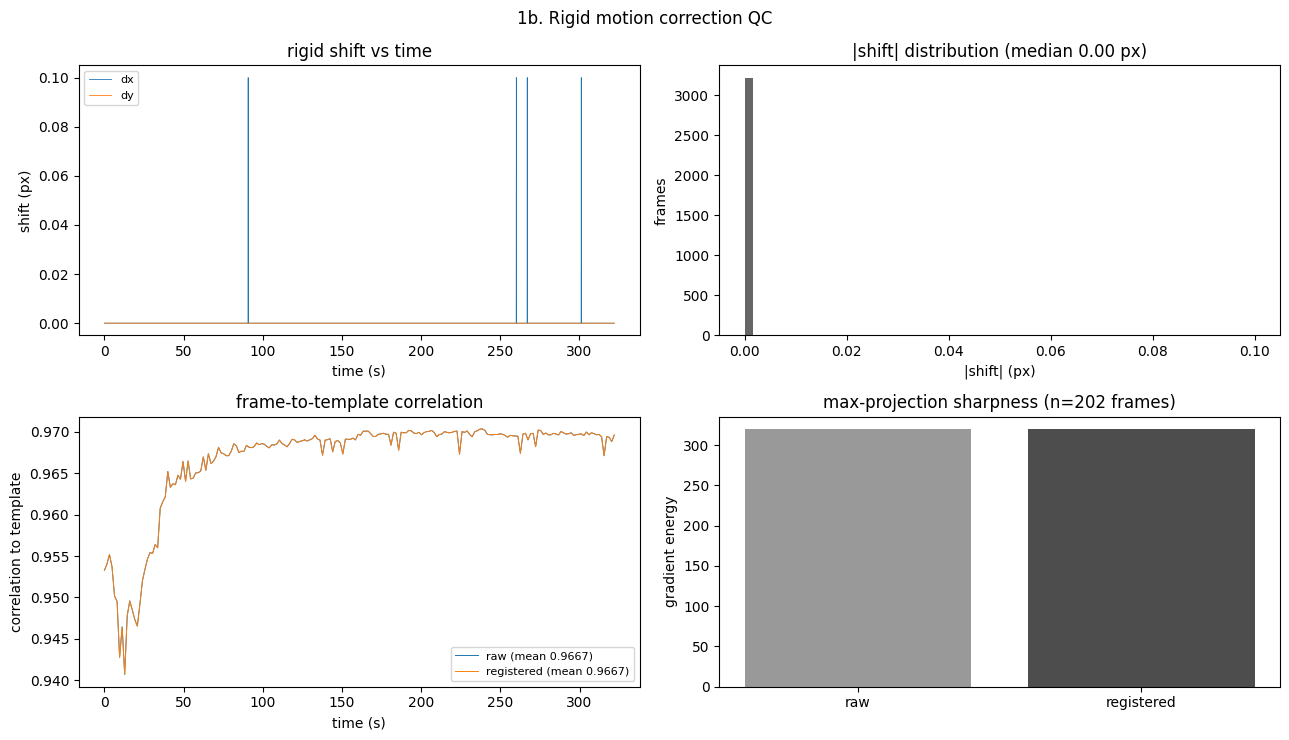

frame-to-template correlation: raw 0.9667 -> registered 0.9667
max-projection sharpness: raw 319.6 -> registered 319.6


In [150]:
from scipy.ndimage import shift as ndshift

QC_STEP = max(1, n_frames // 200)       # subsample: registering 200 frames twice is enough
qc_idx = np.arange(0, n_frames, QC_STEP)


def _sharpness(img):
    """Gradient energy -- motion smears edges, so a sharper max projection means less motion."""
    gy, gx = np.gradient(img.astype(np.float32))
    return float(np.mean(gy ** 2 + gx ** 2))


def _corr_to_template(img):
    a = (img - img.mean()).ravel(); b = (mc_template - mc_template.mean()).ravel()
    return float(a @ b / np.sqrt((a @ a) * (b @ b)))


raw_c, reg_c, raw_max, reg_max = [], [], None, None
for i in tqdm(qc_idx, desc="motion QC"):
    f = load_frame(int(i)).astype(np.float32)
    g = ndshift(f, shifts[i], order=1, mode="nearest")
    raw_c.append(_corr_to_template(f)); reg_c.append(_corr_to_template(g))
    raw_max = f if raw_max is None else np.maximum(raw_max, f)
    reg_max = g if reg_max is None else np.maximum(reg_max, g)

fig, axes = plt.subplots(2, 2, figsize=(13, 7.5))
axes[0, 0].plot(times_s, shifts[:, 1], lw=0.6, label="dx")
axes[0, 0].plot(times_s, shifts[:, 0], lw=0.6, label="dy")
axes[0, 0].set_xlabel("time (s)"); axes[0, 0].set_ylabel("shift (px)")
axes[0, 0].set_title("rigid shift vs time"); axes[0, 0].legend(fontsize=8)

axes[0, 1].hist(shift_mag, bins=60, color="0.4")
axes[0, 1].set_xlabel("|shift| (px)"); axes[0, 1].set_ylabel("frames")
axes[0, 1].set_title(f"|shift| distribution (median {np.median(shift_mag):.2f} px)")

axes[1, 0].plot(times_s[qc_idx], raw_c, lw=0.7, label=f"raw (mean {np.mean(raw_c):.4f})")
axes[1, 0].plot(times_s[qc_idx], reg_c, lw=0.7, label=f"registered (mean {np.mean(reg_c):.4f})")
axes[1, 0].set_xlabel("time (s)"); axes[1, 0].set_ylabel("correlation to template")
axes[1, 0].set_title("frame-to-template correlation"); axes[1, 0].legend(fontsize=8)

axes[1, 1].bar(["raw", "registered"], [_sharpness(raw_max), _sharpness(reg_max)], color=["0.6", "0.3"])
axes[1, 1].set_ylabel("gradient energy")
axes[1, 1].set_title(f"max-projection sharpness (n={len(qc_idx)} frames)")
fig.suptitle("1b. Rigid motion correction QC")
fig.tight_layout(); save_fig(fig, "1b_motion_qc"); plt.show()

print(f"frame-to-template correlation: raw {np.mean(raw_c):.4f} -> registered {np.mean(reg_c):.4f}")
print(f"max-projection sharpness: raw {_sharpness(raw_max):.1f} -> registered {_sharpness(reg_max):.1f}")


## 2. Preprocess — denoise + background subtraction

Every frame gets two steps before analysis: **denoise** then subtract a per-frame
background percentile (a flat offset that pins the noise floor near zero).

- **2a** previews `raw` vs **NLM** vs **Gaussian** on the first frame, using the suggested
  default parameters, so you can eyeball which denoiser to use.
- **2b** lets you pick the method (`"nlm"` or `"gaussian"`) and tune its parameters (defaults
  provided), then builds the cached `load_preprocessed(i)` that every downstream section uses.

### 2a. Compare denoisers (raw vs NLM vs Gaussian, default params)

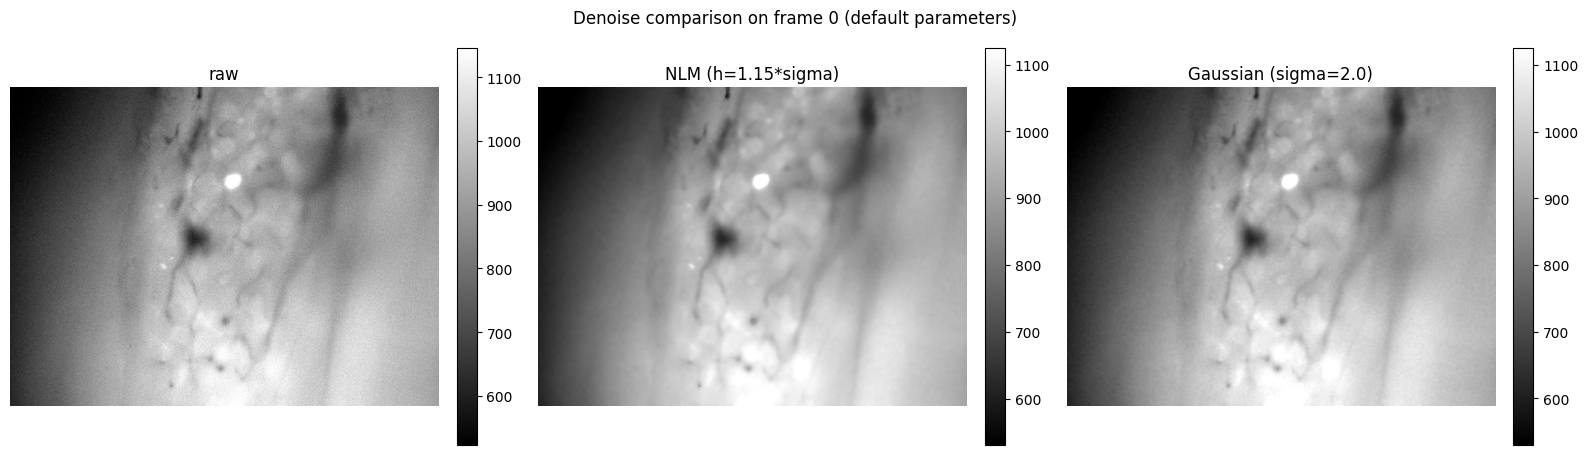

In [151]:
from scipy.ndimage import convolve as _ndconvolve, gaussian_filter
from skimage.restoration import denoise_nl_means

# --- Suggested default denoise parameters (override them in 2b if you like) -----
NLM_PATCH_SIZE = 5        # px, patch size for patch-distance comparison
NLM_PATCH_DISTANCE = 6    # px, max search radius for similar patches
NLM_H_FACTOR = 1.15       # NLM cut-off distance, scaled by the estimated noise sigma
GAUSSIAN_SIGMA = 2.0      # px, Gaussian blur width

# Robust per-frame noise sigma via Immerkaer's Laplacian method (numpy/scipy only, so we
# avoid skimage.estimate_sigma, which needs PyWavelets). NLM scales its `h` by this.
_LAPLACIAN = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float32)


def estimate_noise_sigma(frame: np.ndarray) -> float:
    h, w = frame.shape
    response = np.abs(_ndconvolve(frame, _LAPLACIAN, mode="nearest"))
    return float(response.sum() * np.sqrt(0.5 * np.pi) / (6.0 * (w - 2) * (h - 2)))


def denoise_nlm(frame, patch_size=None, patch_distance=None, h_factor=None):
    """Non-local-means denoise; params default to the suggestions above."""
    patch_size = NLM_PATCH_SIZE if patch_size is None else patch_size
    patch_distance = NLM_PATCH_DISTANCE if patch_distance is None else patch_distance
    h_factor = NLM_H_FACTOR if h_factor is None else h_factor
    sigma = estimate_noise_sigma(frame)
    return denoise_nl_means(frame, h=h_factor * sigma, sigma=sigma, fast_mode=True,
                            patch_size=patch_size, patch_distance=patch_distance, channel_axis=None)


def denoise_gaussian(frame, sigma=None):
    """Gaussian-blur denoise; sigma defaults to GAUSSIAN_SIGMA."""
    return gaussian_filter(frame, sigma=GAUSSIAN_SIGMA if sigma is None else sigma)


# Compare raw vs NLM vs Gaussian on the first frame, using the defaults above.
raw0 = load_frame(0).astype(np.float32)
panels = [
    ("raw", raw0),
    (f"NLM (h={NLM_H_FACTOR}*sigma)", denoise_nlm(raw0)),
    (f"Gaussian (sigma={GAUSSIAN_SIGMA})", denoise_gaussian(raw0)),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (title, img) in zip(axes, panels):
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.axis("off")
fig.suptitle("Denoise comparison on frame 0 (default parameters)")
fig.tight_layout(); save_fig(fig, "2a_denoise_comparison"); plt.show()

### 2b. Choose the denoise method and parameters

Set `DENOISE_METHOD` to `"nlm"` or `"gaussian"` and adjust the parameters below (the values
shown are the suggested defaults). This cell defines `preprocess_frame` / `load_preprocessed`,
which cache one `.npy` per frame under `analysis_cache/` — keyed by method, so switching
method or params doesn't clash with a previous cache. NLM is ~0.5 s/frame, so the first full
pass is slow; later sections reuse the cache.

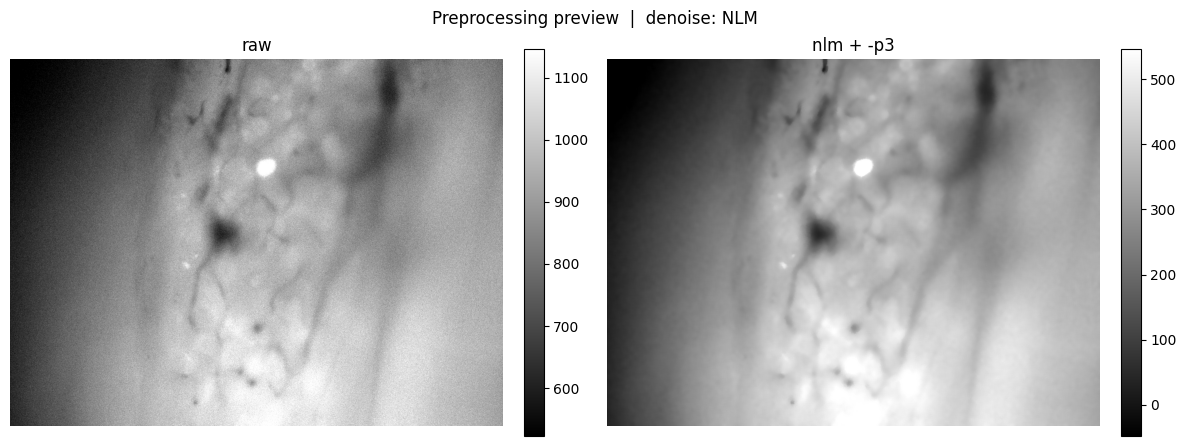

In [152]:
# --- Pick the denoise method and (optionally) tune its parameters ---------------
DENOISE_METHOD = "nlm"     # "nlm" (recommended) or "gaussian"

# NLM parameters (used when DENOISE_METHOD == "nlm"); suggested defaults:
NLM_PATCH_SIZE = 5
NLM_PATCH_DISTANCE = 6
NLM_H_FACTOR = 1.15
# Gaussian parameter (used when DENOISE_METHOD == "gaussian"); suggested default:
GAUSSIAN_SIGMA = 2.0
# Background subtraction: subtract this per-frame intensity percentile (suggested default):
BACKGROUND_PERCENTILE = 3

# Human-readable tag stamped onto every downstream figure/movie title.
METHOD_LABEL = DENOISE_METHOD.upper()


def preprocess_frame(frame: np.ndarray) -> np.ndarray:
    """Denoise (per DENOISE_METHOD) then subtract the per-frame background percentile."""
    frame = frame.astype(np.float32)
    if DENOISE_METHOD == "nlm":
        frame = denoise_nlm(frame, NLM_PATCH_SIZE, NLM_PATCH_DISTANCE, NLM_H_FACTOR)
    elif DENOISE_METHOD == "gaussian":
        frame = denoise_gaussian(frame, GAUSSIAN_SIGMA)
    else:
        raise ValueError(f"DENOISE_METHOD must be 'nlm' or 'gaussian', got {DENOISE_METHOD!r}")
    return (frame - np.percentile(frame, BACKGROUND_PERCENTILE)).astype(np.float32)


# Preprocessed frames are cached one-per-.npy, keyed by method AND its parameters.
_PREP_KEY = param_digest(DENOISE_METHOD, NLM_PATCH_SIZE, NLM_PATCH_DISTANCE, NLM_H_FACTOR,
                         GAUSSIAN_SIGMA, BACKGROUND_PERCENTILE, CHANNEL)
_PREP_DIR = CACHE_DIR / f"preprocessed_{DENOISE_METHOD}_ch{CHANNEL}_{_PREP_KEY}"
_PREP_DIR.mkdir(exist_ok=True)


def load_preprocessed(i: int) -> np.ndarray:
    """Preprocessed frame i, computed once and cached to disk."""
    cache_file = _PREP_DIR / f"{i:07d}.npy"
    if cache_file.exists():
        return np.load(cache_file)
    out = preprocess_frame(load_frame(i))
    np.save(cache_file, out)
    return out


# Before/after preview with the selected method.
raw0 = load_frame(0).astype(np.float32)
prep0 = load_preprocessed(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, img, title in [(axes[0], raw0, "raw"),
                       (axes[1], prep0, f"{DENOISE_METHOD} + -p{BACKGROUND_PERCENTILE}")]:
    vmin, vmax = np.percentile(img, [1, 99])
    im = ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); ax.axis("off")
fig.suptitle(f"Preprocessing preview  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"2b_preprocessed_preview_{DENOISE_METHOD}"); plt.show()

## 3. Visualize

Views of the recording, plus an optional interactive napari viewer. Every figure/movie title
is stamped with the denoise method chosen in §2b.
1. ROIs (from your label TIFF) **marked on the max-projection map**.
2. **MP4** of the whole field over time, with the **ROI mask overlaid** so you can see where
   each ROI sits.
3. **dF/F trace of every ROI**.

### 3a. ROI masks

ROIs come from the integer label TIFF set in Config (`0` = background, each positive
integer = one ROI). If you don't have one yet, paint it in the **napari cell** below and
save it to `ROI_LABEL_PATH`.

In [153]:
def load_roi_masks(path: Path = ROI_LABEL_PATH, expected_shape=frame_shape):
    label_map = np.squeeze(tifffile.imread(path))
    if label_map.shape != expected_shape:
        raise ValueError(f"ROI label shape {label_map.shape} != frame shape {expected_shape}")
    label_map = np.rint(label_map).astype(np.int32)
    ids = np.unique(label_map)
    ids = ids[ids > 0]
    if ids.size == 0:
        raise ValueError(f"No positive labels in {path}")
    return label_map, ids, [label_map == i for i in ids]


label_map, roi_ids, roi_masks = load_roi_masks()
roi_names = [f"ROI {int(i)}" for i in roi_ids]
print(f"{len(roi_masks)} ROIs; areas (px): {[int(m.sum()) for m in roi_masks]}")

40 ROIs; areas (px): [2601, 2449, 3717, 3864, 3520, 3269, 4326, 3888, 4519, 5036, 2520, 1439, 2492, 1314, 3249, 5238, 3068, 3547, 3018, 3695, 3054, 2743, 1607, 2304, 2094, 2772, 2599, 3801, 3182, 1207, 4916, 7412, 4387, 2956, 2477, 6815, 6444, 6585, 4903, 3770]


### 3b. ROIs marked on the max-projection map

The pixelwise max over the whole recording (raw frames, cached) with every ROI outlined and
numbered — a static reference for where the ROIs sit.

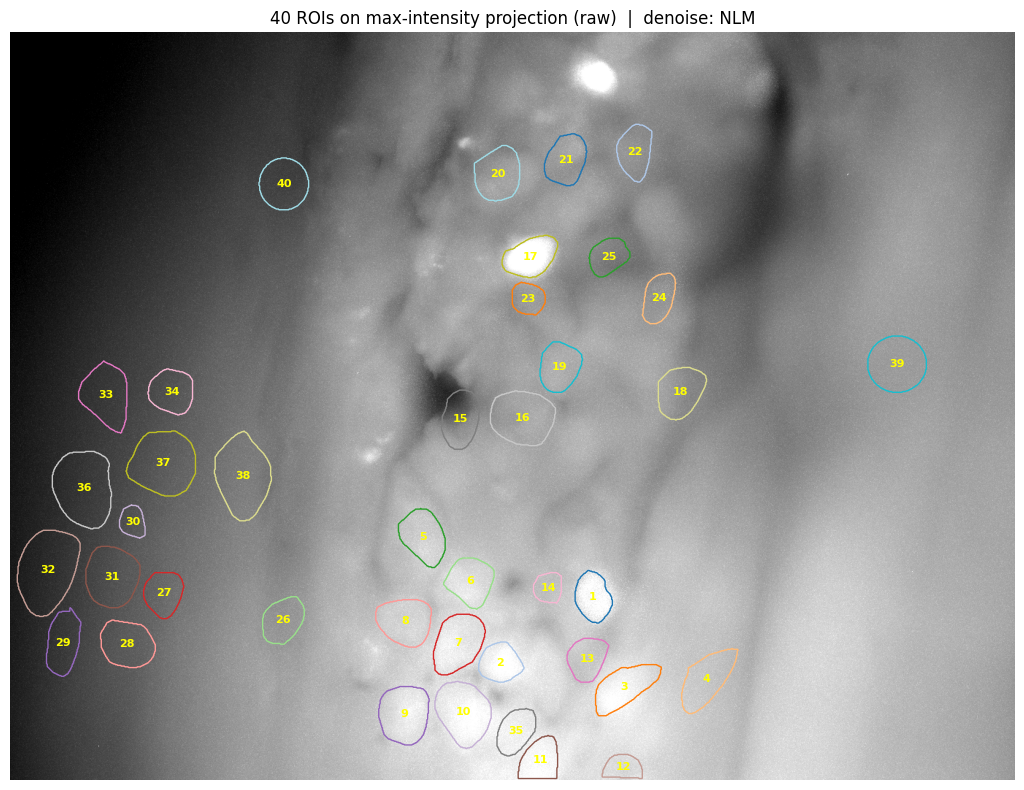

In [154]:
MAXPROJ_PATH = CACHE_DIR / f"max_projection_ch{CHANNEL}.npy"


def max_projection(path=MAXPROJ_PATH, overwrite=False):
    if path.exists() and not overwrite:
        return np.load(path)
    acc = None
    for i in tqdm(range(n_frames), desc="max projection"):
        f = load_frame(i)
        acc = f.copy() if acc is None else np.maximum(acc, f)
    np.save(path, acc)
    return acc


max_proj = max_projection()
vmin, vmax = np.percentile(max_proj, [2, 99.5])
fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(max_proj, cmap="gray", vmin=vmin, vmax=vmax)
for j, (m, name) in enumerate(zip(roi_masks, roi_names)):
    color = plt.cm.tab20(j % 20)
    ax.contour(m, levels=[0.5], colors=[color], linewidths=1.0)
    ys, xs = np.nonzero(m)
    ax.text(xs.mean(), ys.mean(), str(int(roi_ids[j])), color="yellow",
            fontsize=8, ha="center", va="center", weight="bold")
ax.set_title(f"{len(roi_masks)} ROIs on max-intensity projection (raw)  |  denoise: {METHOD_LABEL}")
ax.axis("off")
fig.tight_layout(); save_fig(fig, f"3b_rois_on_max_projection_{DENOISE_METHOD}"); plt.show()

### 3c. MP4 of the whole field (with ROI mask overlay)

Streams every frame to an H.264 MP4 without holding the stack in RAM, with the ROI mask
outlines + numbers drawn on top so you can see where each ROI sits in the moving field. A
single global contrast range keeps brightness from flickering. Requires `ffmpeg` on PATH.

`FRAME_STEP = 1` writes **every** acquired frame (3220 here), so nothing is skipped.

**What `MOVIE_DPI` does and does not buy.** The figure is 9.6x7.2 in, so 600 dpi renders a
5760x4320 px movie — but the source frames are only 1024x1376, so the image content is
*upsampled ~4x* and gains no real detail. What genuinely sharpens is the vector overlay: ROI
outlines, ID numbers and the title. Two consequences worth knowing before you run it: encoding
3220 frames at that size is slow and the file is large (CRF 18 keeps it honest rather than
blocky), and 5760x4320 exceeds what many players and browsers will decode — including the
inline player below, which may show a blank box even though the file is fine. If you want
maximum *image* fidelity instead of maximum canvas, render at the native pixel grid
(`figsize=(1376/100, 1024/100)`, `MOVIE_DPI = 100`) so no interpolation happens at all.

In [155]:
from matplotlib import animation
from IPython.display import FileLink, Video, display

FRAME_STEP = 1          # 1 = every frame (no decimation); larger = smaller/faster preview
PLAYBACK_FPS = 60       # native rate is ~10 Hz, so 60 fps plays back ~6x real time
OVERLAY_ROIS = True     # draw ROI mask outlines + numbers on the movie (set False for a bare field)
MOVIE_DPI = 600         # 9.6x7.2 in -> 5760x4320 px. NOTE: the frames are only 1024x1376, so
                        # this upsamples the image ~4x; what actually gets sharper is the
                        # vector overlay (ROI outlines, ID numbers, title). See the markdown.

# An MP4 must exist as a file to play inline. When SAVE_OUTPUTS is False we keep it in the
# cache (a working dir, not committed); when True we write it to OUTPUT_DIR (main_output/).
MOVIE_DIR = OUTPUT_DIR if SAVE_OUTPUTS else CACHE_DIR
MOVIE_PATH = MOVIE_DIR / (f"whole_field_ch{CHANNEL}_step{FRAME_STEP}"
                          f"{'_roi' if OVERLAY_ROIS else ''}_dpi{MOVIE_DPI}.mp4")


def render_movie(path=MOVIE_PATH, frame_step=FRAME_STEP, playback_fps=PLAYBACK_FPS,
                 overlay_rois=OVERLAY_ROIS, dpi=MOVIE_DPI, overwrite=False):
    if path.exists() and path.stat().st_size > 0 and not overwrite:
        print(f"Using cached movie: {path}")
        return path
    if not animation.writers.is_available("ffmpeg"):
        raise RuntimeError("ffmpeg is required (macOS: brew install ffmpeg).")
    path.parent.mkdir(parents=True, exist_ok=True)

    rows = np.arange(0, n_frames, frame_step)
    sample = np.linspace(0, n_frames - 1, min(12, n_frames)).astype(int)
    vmin, vmax = np.percentile(np.concatenate([load_frame(int(r))[::8, ::8].ravel() for r in sample]), [1, 99])

    fig, ax = plt.subplots(figsize=(9.6, 7.2))
    art = ax.imshow(load_frame(int(rows[0])), cmap="gray", vmin=vmin, vmax=max(vmax, vmin + 1))
    if overlay_rois:  # ROI outlines + id numbers are static, so draw them once
        for j, m in enumerate(roi_masks):
            ax.contour(m, levels=[0.5], colors=[plt.cm.tab20(j % 20)], linewidths=0.7)
            ys, xs = np.nonzero(m)
            ax.text(xs.mean(), ys.mean(), str(int(roi_ids[j])), color="yellow",
                    fontsize=6, ha="center", va="center", weight="bold")
    title = ax.set_title("")
    ax.axis("off"); fig.subplots_adjust(left=0, right=1, bottom=0, top=0.95)

    roi_tag = f" | {len(roi_masks)} ROIs" if overlay_rois else ""
    # Quality-targeted (CRF) rather than a fixed bitrate: at 5760x4320 the old 4000 kbps
    # would spend the extra pixels on compression blocking. bitrate=-1 omits -b:v entirely.
    writer = animation.FFMpegWriter(fps=playback_fps, codec="libx264", bitrate=-1,
                                    extra_args=["-crf", "18", "-preset", "medium",
                                                "-pix_fmt", "yuv420p", "-movflags", "+faststart"])
    with writer.saving(fig, str(path), dpi=dpi):
        for r in tqdm(rows, desc="writing MP4"):
            art.set_data(load_frame(int(r)))
            title.set_text(f"Ch{CHANNEL} | raw frame {int(r)} | t={times_s[int(r)]:.1f}s"
                           f"{roi_tag} | denoise: {METHOD_LABEL}")
            writer.grab_frame()
    plt.close(fig)
    print(f"Saved {len(rows)} frames at {dpi} dpi -> {path} "
          f"({path.stat().st_size / 1024**2:.1f} MB)")
    return path


movie_path = render_movie()
display(Video(str(movie_path), embed=False, html_attributes="controls preload='metadata'"))
display(FileLink(str(movie_path), result_html_prefix="Download MP4: "))

writing MP4:   0%|          | 0/3220 [00:00<?, ?it/s]

Saved 3220 frames at 600 dpi -> analysis_cache/whole_field_ch0_step1_roi_dpi600.mp4 (6632.9 MB)


/Users/samsonho/KSLSpikeInference/main/analysis_cache/whole_field_ch0_step1_roi_dpi600.mp4

### 3d. dF/F trace of every ROI

One streaming pass averages the preprocessed pixels inside each ROI (cached), then a
rolling low-percentile baseline converts each fluorescence trace to fractional dF/F.
`dff` has shape `(n_frames, n_rois)` and is reused by sections 4 and 5.

dF/F (3220, 40)  range [-0.08, 0.37]


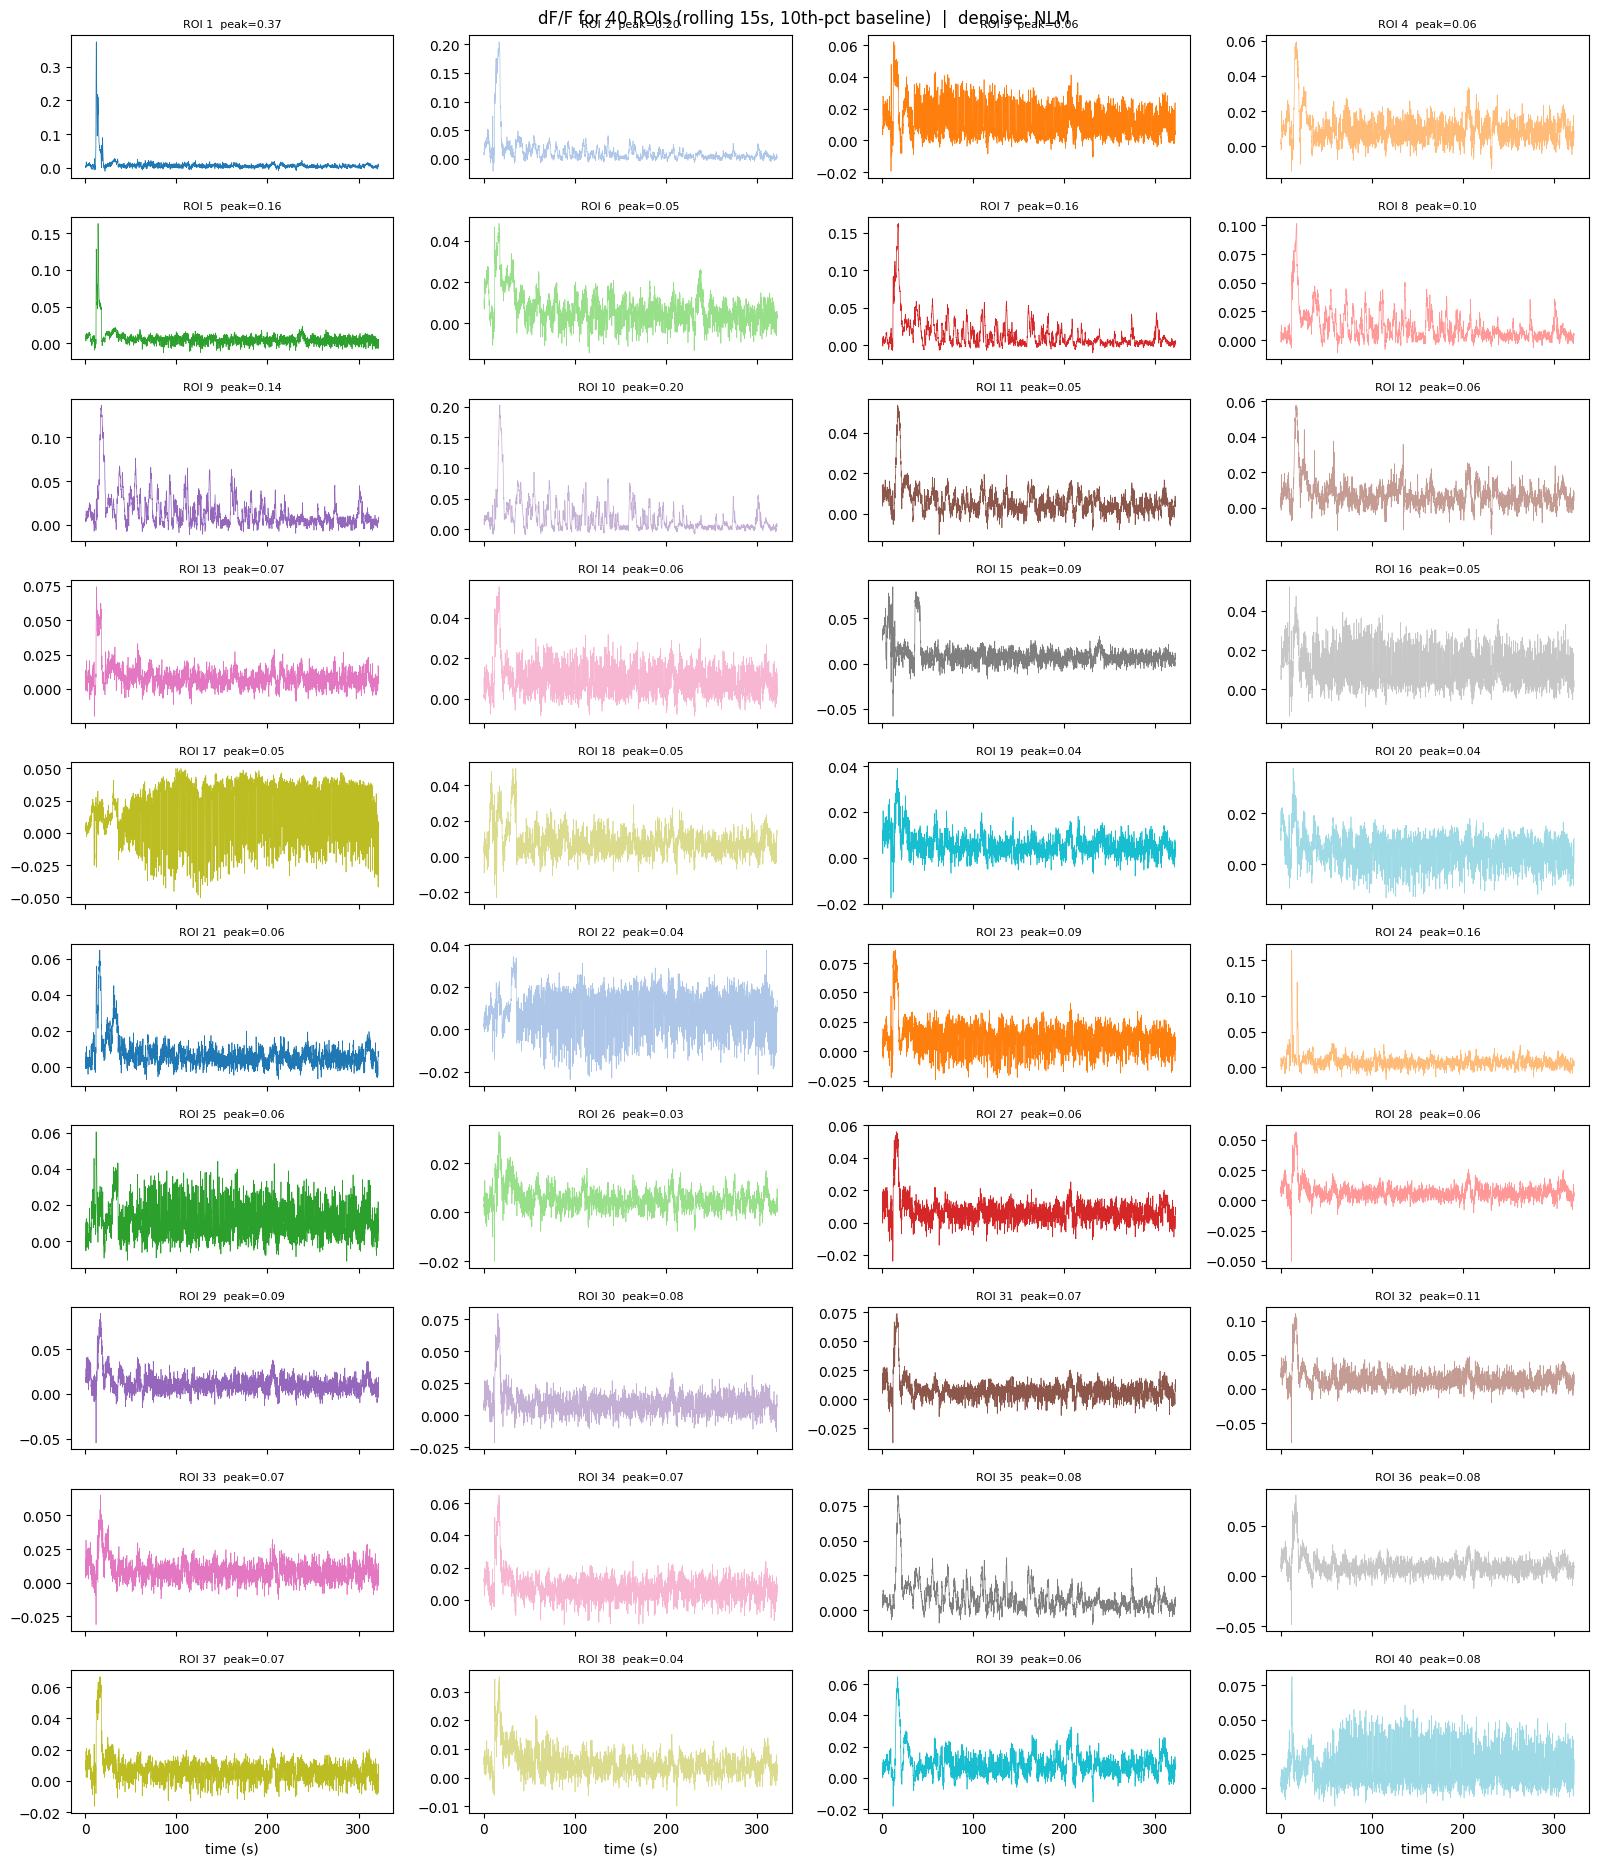

In [156]:
from scipy.ndimage import percentile_filter

# Keyed by the preprocessing parameters AND the ROI mask content, not just its count.
TRACES_CACHE = CACHE_DIR / (f"roi_traces_{DENOISE_METHOD}_ch{CHANNEL}_n{len(roi_masks)}"
                            f"_{param_digest(_PREP_KEY, label_map)}.npy")


def extract_roi_traces(masks, cache_path=TRACES_CACHE, overwrite=False):
    """Mean preprocessed intensity inside each mask, per frame -> (n_frames, n_rois)."""
    if cache_path.exists() and not overwrite:
        F = np.load(cache_path)
        if F.shape == (n_frames, len(masks)):
            return F
    pixel_idx = [np.flatnonzero(m.ravel()) for m in masks]
    F = np.empty((n_frames, len(masks)), dtype=np.float32)
    for i in tqdm(range(n_frames), desc=f"extracting {len(masks)} ROI traces"):
        flat = load_preprocessed(i).ravel()
        for j, px in enumerate(pixel_idx):
            F[i, j] = flat[px].mean()
    np.save(cache_path, F)
    return F


def compute_dff(F):
    win = max(3, round(BASELINE_WINDOW_S / np.median(np.diff(times_s))))
    dff = np.empty_like(F)
    for j in range(F.shape[1]):
        f0 = np.clip(percentile_filter(F[:, j], BASELINE_PERCENTILE, size=win, mode="nearest"), 1e-3, None)
        dff[:, j] = (F[:, j] - f0) / f0
    return dff


roi_F = extract_roi_traces(roi_masks)
dff = compute_dff(roi_F)
print(f"dF/F {dff.shape}  range [{dff.min():.2f}, {dff.max():.2f}]")

# Small-multiples: dF/F for every ROI.
n_cols = 4
n_rows = int(np.ceil(len(roi_names) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 1.9 * n_rows), sharex=True)
for j, ax in enumerate(axes.ravel()):
    if j >= len(roi_names):
        ax.axis("off"); continue
    ax.plot(times_s, dff[:, j], lw=0.5, color=plt.cm.tab20(j % 20))
    ax.set_title(f"{roi_names[j]}  peak={dff[:, j].max():.2f}", fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"dF/F for {len(roi_names)} ROIs (rolling {BASELINE_WINDOW_S}s, "
             f"{BASELINE_PERCENTILE}th-pct baseline)  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"3d_dff_per_roi_{DENOISE_METHOD}"); plt.show()

### 3e. napari interactive viewer *(optional — off by default)*

Set `USE_NAPARI = True` in Config to open the recording in napari: the raw stack is added
lazily (via dask, so nothing is materialized), together with the max projection and an
editable ROI **Labels** layer. Paint ROIs with the brush, then run the save line to write
them to `ROI_LABEL_PATH` and re-run section 3a onward. Needs `napari` + `dask`, and a Qt
event loop (`%gui qt6`) in JupyterLab.

In [157]:
if USE_NAPARI:
    import dask.array as da
    import napari

    lazy = da.stack([
        da.from_delayed(da.delayed(load_frame)(i), shape=frame_shape, dtype=np.uint16)
        for i in range(n_frames)
    ], axis=0)

    viewer = napari.Viewer()
    viewer.add_image(lazy, name="raw_stack")
    viewer.add_image(max_proj, name="max_projection")
    roi_layer = viewer.add_labels(label_map.astype(np.uint16), name="ROI mask", opacity=0.6)

    # To persist edits, run this after painting:
    #   tifffile.imwrite(ROI_LABEL_PATH, roi_layer.data.astype(np.uint16))
    print("napari open. Paint ROIs on 'ROI mask', then save with the commented line above.")
else:
    print("napari disabled (USE_NAPARI = False). Set it True in Config to enable.")

napari disabled (USE_NAPARI = False). Set it True in Config to enable.


### 3f. Hardened trace extraction — no blur, neuropil-corrected, with negative controls

§3d above is the original path and is kept for diffing (`LEGACY_PIPELINE = True` sends §5
back to it). This section replaces it with three fixes, all of which change the §5
correlation, plus the controls that let us tell whether that correlation is real.

**No spatial denoising (P0.3).** For a linear filter, the ROI mean of a blurred image is
approximately the blurred ROI mean — identical except at the boundary. So blurring buys
essentially nothing for trace SNR (averaging thousands of pixels inside the ROI is already
the dominant denoiser) while it *does* leak neighbouring somata and background across ROI
edges, which manufactures correlation between nearby ROIs. Traces therefore come from the
**raw** frames; NLM/Gaussian remain display-only for §2 and §3b/§3c.

**Local neuropil subtraction (P0.4).** Per ROI, an annulus between `NEUROPIL_R_IN_UM` and
`NEUROPIL_R_OUT_UM`, with every ROI's own halo removed so no annulus contains another cell.
`F_corr = F_roi − alpha·(F_neuropil − median F_neuropil)` — the neuropil **fluctuation** is
what gets removed, not its absolute level. Subtracting the level outright also strips the
ROI's own DC, and at a widefield alpha near 1 that drives F_corr to zero (measured: half the
samples ≤ 0), which makes a ratio like dF/F meaningless.

The familiar `alpha = 0.7` is a **two-photon** convention (suite2p / Chen 2013), and this is
**widefield**. Without optical sectioning every pixel integrates fluorescence from the whole
depth of the tissue, so contamination is close to *complete* and alpha should sit near 1.0 —
which is what the data say (measured median ≈ 1.0). `NEUROPIL_ALPHA_MODE = "estimated"`
therefore uses the per-ROI slope of `F_roi` on `F_neuropil` over quiet frames; set it to
`"fixed"` to force `NEUROPIL_ALPHA` instead. Both numbers are always printed.

**Background (P0.5).** The old per-frame `np.percentile(frame, 3)` is a *scalar*, so every
ROI carried the same `−b(t)` term and any fast fluctuation in it appeared in all ROIs at
once, feeding straight into §5a. Default is now `BACKGROUND_MODE = "none"` and the neuropil
annulus does the job locally. `b(t)` is still recorded either way and enters the §5 matrix
as a **pseudo-ROI**: if it correlates with the real ROIs, §5a is suspect.

**Negative controls.** `N_BLANK_ROIS` soma-free regions go through the identical pipeline.
They are auto-placed in the dimmest parts of the field that are far from every ROI (so they
are reproducible, not hand-drawn — repaint them into the label TIFF if you prefer). Any
event detected in a blank ROI, or any blank-to-cell correlation, is artifact evidence.

**Censoring.** `frame_valid` is False where |shift| exceeds `MOTION_MAX_SHIFT_FRAC` × the
median ROI radius. Those bins are set NaN and are never interpolated — except for the
CASCADE bridge in §4, which cannot accept NaN; there they are interpolated and the affected
bins are masked out of every statistic.


ROI radius 32.2 px (28.3 um); annulus 3.4-13.6 px, 1357-3745 px per ROI
frame_valid: 3220/3220 frames kept (0.00% censored at |shift| > 16.1 px)


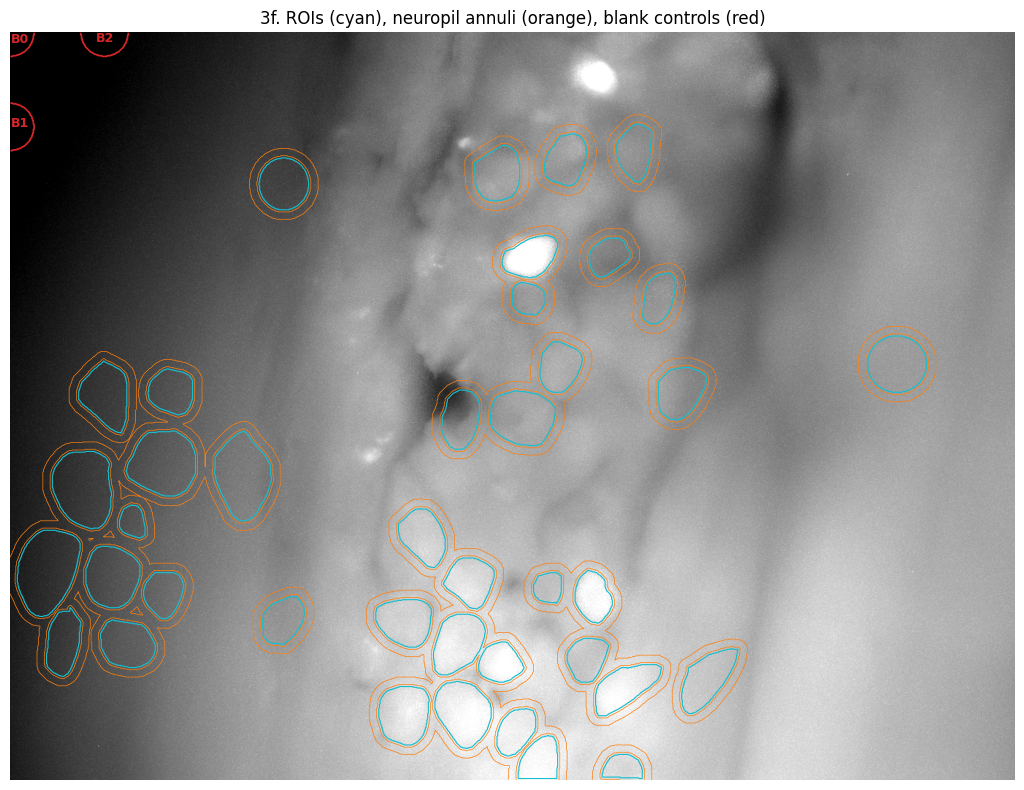

In [158]:
from scipy.ndimage import distance_transform_edt

if pixel_um is None:
    raise ValueError("PIXEL_SIZE_UM is unknown -- set it in Config; the annulus is defined in um.")
r_in_px, r_out_px = NEUROPIL_R_IN_UM / pixel_um, NEUROPIL_R_OUT_UM / pixel_um

# Distance from ANY ROI: 0 inside a soma, so `dist_all > r_in_px` removes every soma and
# its halo from every annulus -- no annulus can contain another cell.
dist_all = distance_transform_edt(label_map == 0)
outside_all = dist_all > r_in_px

neuropil_masks = []
for m in roi_masks:
    d = distance_transform_edt(~m)
    neuropil_masks.append((d > r_in_px) & (d <= r_out_px) & outside_all)
annulus_px = np.array([int(a.sum()) for a in neuropil_masks])

# Blank ROIs: dimmest spots far from every soma, spaced apart. Reproducible negative controls.
roi_radius_px = float(np.sqrt(np.median([m.sum() for m in roi_masks]) / np.pi))
far = dist_all > (r_out_px + roi_radius_px)
score = np.where(far, gaussian_filter(max_proj.astype(np.float32), roi_radius_px), np.inf)
yy, xx = np.indices(frame_shape)
blank_masks = []
for _ in range(N_BLANK_ROIS):
    cy, cx = np.unravel_index(np.argmin(score), score.shape)
    blank = (yy - cy) ** 2 + (xx - cx) ** 2 <= roi_radius_px ** 2
    blank_masks.append(blank)
    score[(yy - cy) ** 2 + (xx - cx) ** 2 <= (4 * roi_radius_px) ** 2] = np.inf   # keep them apart

frame_valid = shift_mag <= MOTION_MAX_SHIFT_FRAC * roi_radius_px
print(f"ROI radius {roi_radius_px:.1f} px ({roi_radius_px * pixel_um:.1f} um); "
      f"annulus {r_in_px:.1f}-{r_out_px:.1f} px, {annulus_px.min()}-{annulus_px.max()} px per ROI")
if (annulus_px < 50).any():
    print(f"  ! {(annulus_px < 50).sum()} ROI(s) have a near-empty annulus -- neuropil estimate is weak there")
print(f"frame_valid: {frame_valid.sum()}/{n_frames} frames kept "
      f"({100 * (1 - frame_valid.mean()):.2f}% censored at |shift| > "
      f"{MOTION_MAX_SHIFT_FRAC * roi_radius_px:.1f} px)")

fig, ax = plt.subplots(figsize=(11, 8))
_vmin, _vmax = np.percentile(max_proj, [2, 99.5])
ax.imshow(max_proj, cmap="gray", vmin=_vmin, vmax=_vmax)
ax.contour(np.sum(roi_masks, axis=0) > 0, levels=[0.5], colors=["tab:cyan"], linewidths=0.8)
ax.contour(np.sum(neuropil_masks, axis=0) > 0, levels=[0.5], colors=["tab:orange"], linewidths=0.5)
for k, b in enumerate(blank_masks):
    ax.contour(b, levels=[0.5], colors=["tab:red"], linewidths=1.2)
    by, bx = np.nonzero(b)
    ax.text(bx.mean(), by.mean(), f"B{k}", color="tab:red", fontsize=9, ha="center", weight="bold")
ax.set_title("3f. ROIs (cyan), neuropil annuli (orange), blank controls (red)"); ax.axis("off")
fig.tight_layout(); save_fig(fig, "3f_masks"); plt.show()


In [159]:
# One streaming pass over the RAW frames computes every trace level at once: soma,
# neuropil annulus, blank control, and the background summary b(t).
_GROUPS = roi_masks + neuropil_masks + blank_masks
_COUNTS = np.array([int(m.sum()) for m in _GROUPS])
if (_COUNTS == 0).any():
    raise ValueError("an ROI/annulus/blank mask is empty -- widen NEUROPIL_R_OUT_UM or repaint")
_ROWS = np.concatenate([np.nonzero(m)[0] for m in _GROUPS]).astype(np.int64)
_COLS = np.concatenate([np.nonzero(m)[1] for m in _GROUPS]).astype(np.int64)
_OFFSETS = np.concatenate([[0], np.cumsum(_COUNTS)[:-1]])
_H, _W = frame_shape

TRACES_3F = CACHE_DIR / (f"traces3f_ch{CHANNEL}_{param_digest(label_map, shifts, TRACE_DENOISE, BACKGROUND_MODE, BACKGROUND_FIELD_SIGMA, NEUROPIL_R_IN_UM, NEUROPIL_R_OUT_UM, N_BLANK_ROIS)}.npz")


def extract_levels(overwrite=False):
    """Mean raw intensity per group per frame, with the motion shift applied to the mask
    indices (integer): mask pixel (r, c) samples raw pixel (r - dy, c - dx)."""
    if TRACES_3F.exists() and not overwrite:
        with np.load(TRACES_3F) as d:
            return d["levels"], d["b_t"]
    levels = np.empty((n_frames, len(_GROUPS)), dtype=np.float32)
    b_t = np.empty(n_frames, dtype=np.float32)
    for i in tqdm(range(n_frames), desc=f"extracting {len(_GROUPS)} traces"):
        raw = load_frame(i).astype(np.float32)
        # b(t) is recorded even when nothing is subtracted -- it is a diagnostic trace.
        b_t[i] = np.percentile(raw[::4, ::4], BACKGROUND_PERCENTILE)
        if BACKGROUND_MODE == "field":                  # spatially varying, not a scalar
            frame = raw - gaussian_filter(raw, BACKGROUND_FIELD_SIGMA)
        elif BACKGROUND_MODE == "scalar_pct":           # legacy behaviour, kept for diffing
            frame = raw - b_t[i]
        else:
            frame = raw
        dy, dx = np.rint(shifts[i]).astype(int)
        rr = np.clip(_ROWS - dy, 0, _H - 1)
        cc = np.clip(_COLS - dx, 0, _W - 1)
        levels[i] = np.add.reduceat(frame.ravel()[rr * _W + cc], _OFFSETS) / _COUNTS
    np.savez_compressed(TRACES_3F, levels=levels, b_t=b_t)
    return levels, b_t


levels, b_t = extract_levels()
n_roi = len(roi_masks)
F_roi = levels[:, :n_roi]
F_neuropil = levels[:, n_roi:2 * n_roi]
F_blank = levels[:, 2 * n_roi:]
print(f"F_roi {F_roi.shape}, F_neuropil {F_neuropil.shape}, F_blank {F_blank.shape}; "
      f"b(t) range [{b_t.min():.1f}, {b_t.max():.1f}]")


F_roi (3220, 40), F_neuropil (3220, 40), F_blank (3220, 3); b(t) range [524.0, 586.0]


neuropil alpha: fixed 1.0 vs estimated median 1.00 [0.85, 1.10] -> using estimated
dF/F (3220, 40) (hardened 3f traces); 0 censored bins interpolated for CASCADE only


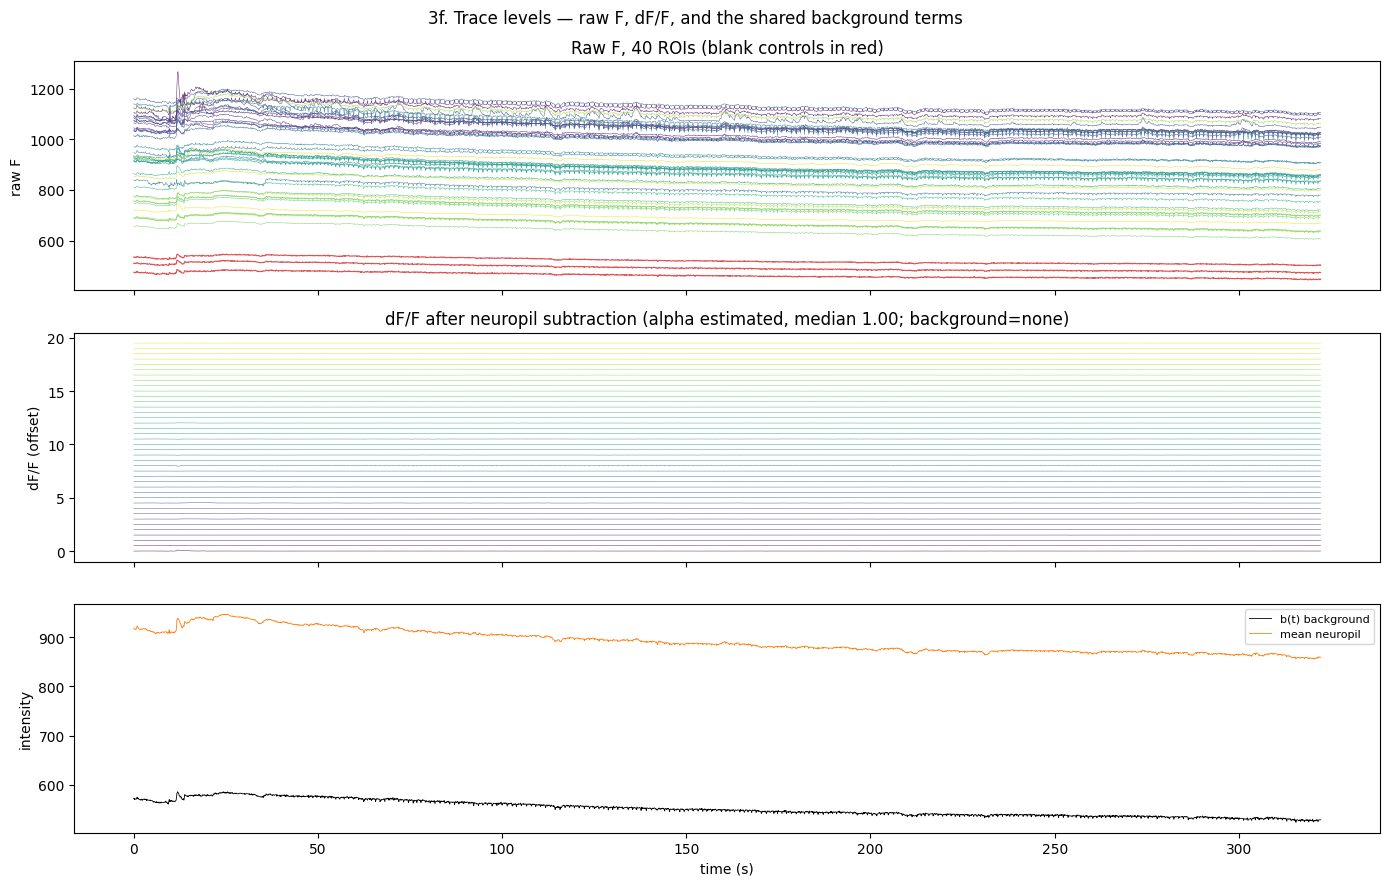

In [160]:
_WIN = max(3, round(BASELINE_WINDOW_S / np.median(np.diff(times_s))))


def _rolling_f0(x):
    return np.clip(percentile_filter(x, BASELINE_PERCENTILE, size=_WIN, mode="nearest"), 1e-3, None)


def to_dff(F, valid=None):
    """Rolling low-percentile dF/F; censored frames become NaN and are never interpolated."""
    out = np.empty_like(F, dtype=np.float32)
    for j in range(F.shape[1]):
        f0 = _rolling_f0(F[:, j])
        out[:, j] = (F[:, j] - f0) / f0
    if valid is not None:
        out[~valid] = np.nan
    return out


# alpha: the cortex-derived 0.7 vs the slope of F_roi on F_neuropil over quiet frames.
_dff_raw = to_dff(F_roi)
alpha_est = np.empty(n_roi)
for j in range(n_roi):
    quiet = _dff_raw[:, j] <= np.percentile(_dff_raw[:, j], 70)   # no-event frames only
    alpha_est[j] = np.polyfit(F_neuropil[quiet, j], F_roi[quiet, j], 1)[0]
alpha_used = alpha_est if NEUROPIL_ALPHA_MODE == "estimated" else np.full(n_roi, NEUROPIL_ALPHA)
print(f"neuropil alpha: fixed {NEUROPIL_ALPHA} vs estimated median {np.median(alpha_est):.2f} "
      f"[{np.percentile(alpha_est, 10):.2f}, {np.percentile(alpha_est, 90):.2f}] "
      f"-> using {NEUROPIL_ALPHA_MODE}")
if abs(np.median(alpha_est) - NEUROPIL_ALPHA) > 0.2:
    print("  ! the two disagree substantially -- both are reported; neither is adopted silently.")

# Subtract the neuropil's FLUCTUATION, not its absolute level. Removing alpha*F_neuropil
# outright also removes the ROI's DC, and at the widefield alpha of ~1 that drove half of
# F_corr to <= 0, making dF/F (which divides by a rolling baseline) meaningless.
F_corr = F_roi - alpha_used * (F_neuropil - np.median(F_neuropil, axis=0))
F0_raw = np.array([_rolling_f0(F_roi[:, j]) for j in range(n_roi)]).T   # pre-correction, for QC
if (F_corr <= 0).any():
    print(f"  ! {(F_corr <= 0).mean() * 100:.2f}% of F_corr samples are <= 0 "
          f"(alpha median {np.median(alpha_used):.2f})")

dff_corr = to_dff(F_corr, frame_valid)
dff_blank = to_dff(F_blank, frame_valid)
dff_active = dff if LEGACY_PIPELINE else dff_corr     # what sections 4-12 consume
dff_cascade = np.where(np.isfinite(dff_active), dff_active, 0.0).astype(np.float32)
for j in range(dff_active.shape[1]):                  # CASCADE cannot accept NaN
    col = dff_active[:, j]
    if not np.isfinite(col).all():
        dff_cascade[:, j] = np.interp(times_s, times_s[np.isfinite(col)], col[np.isfinite(col)])
print(f"dF/F {dff_active.shape} ({'LEGACY 3d' if LEGACY_PIPELINE else 'hardened 3f'} traces); "
      f"{(~frame_valid).sum()} censored bins interpolated for CASCADE only")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
for j in range(n_roi):
    axes[0].plot(times_s, F_roi[:, j], lw=0.3, color=plt.cm.viridis(j / n_roi))
    axes[1].plot(times_s, dff_corr[:, j] + 0.5 * j, lw=0.3, color=plt.cm.viridis(j / n_roi))
for k in range(F_blank.shape[1]):
    axes[0].plot(times_s, F_blank[:, k], lw=0.8, color="tab:red", alpha=0.8)
axes[0].set_ylabel("raw F"); axes[0].set_title(f"Raw F, {n_roi} ROIs (blank controls in red)")
axes[1].set_ylabel("dF/F (offset)"); axes[1].set_title(
    f"dF/F after neuropil subtraction (alpha {NEUROPIL_ALPHA_MODE}, median "
    f"{np.median(alpha_used):.2f}; background={BACKGROUND_MODE})")
axes[2].plot(times_s, b_t, lw=0.6, color="k", label="b(t) background")
axes[2].plot(times_s, F_neuropil.mean(1), lw=0.6, color="tab:orange", label="mean neuropil")
axes[2].set_xlabel("time (s)"); axes[2].set_ylabel("intensity"); axes[2].legend(fontsize=8)
fig.suptitle("3f. Trace levels — raw F, dF/F, and the shared background terms")
fig.tight_layout(); save_fig(fig, "3f_trace_levels"); plt.show()


### 3g. Motion confound test — which traces are just the field moving?

Rigid registration reduces motion; it does not prove a trace is free of it. A soma sitting on
an intensity gradient still gets a fluorescence wobble that tracks residual shift, and that
wobble is **shared across every ROI**, which is exactly the failure mode §5a is vulnerable to.

Each ROI's dF/F is correlated against `shift_x`, `shift_y` and `|shift|`. Significance is
judged against a **circular-shift null**, not an ordinary p-value: calcium traces are strongly
autocorrelated, so an i.i.d. permutation destroys the very structure that makes the naive
p-value wrong, and would call almost everything significant. Rolling one trace against the
other preserves both autocorrelations.

ROIs flagged here are **not usable** for §5 — report them, do not quietly keep them. The blank
controls are included: they contain no soma, so any motion coupling they show is the pure
artifact amplitude for this field.

`circshift_null()` is defined here and reused by §8, §9 and §12.


In [161]:
def circshift_null(x, y, n_perm=1000, seed=0):
    """(observed r, null distribution, two-sided p) for pearson(x, y).

    The null rolls y circularly, which preserves the autocorrelation of both traces. An
    i.i.d. shuffle would not, and would make almost any smooth calcium trace look significant.
    """
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok] - np.mean(x[ok]), y[ok] - np.mean(y[ok])
    denom = np.sqrt((x @ x) * (y @ y))
    obs = float(x @ y) / denom
    rng = np.random.default_rng(seed)
    null = np.array([float(x @ np.roll(y, int(s))) / denom
                     for s in rng.integers(1, y.size, n_perm)])
    return obs, null, (np.sum(np.abs(null) >= abs(obs)) + 1) / (n_perm + 1)


MOTION_CONFOUND_PERM = 1000
_traces = np.hstack([dff_corr, dff_blank])
_names = roi_names + [f"blank {k}" for k in range(dff_blank.shape[1])]

# A regressor has to carry real information for this to be a test rather than a divide by
# ~zero. Non-zero variance is not enough: at upsample_factor=10 the registration resolution
# is 0.1 px, so a shift trace that only ever moves by one quantization step is measurement
# noise. Require a meaningful fraction of frames to exceed that resolution.
MOTION_RESOLUTION_PX = 1 / 10                  # = 1 / upsample_factor used in 1b
MOTION_MIN_MOVING_FRAC = 0.01                  # at least 1% of frames must exceed it
_moving_frac = float((shift_mag > MOTION_RESOLUTION_PX).mean())
_regressors = {k: v for k, v in (("shift_x", shifts[:, 1]), ("shift_y", shifts[:, 0]),
                                 ("|shift|", shift_mag)) if np.std(v) > 1e-6}
MOTION_TESTABLE = bool(_regressors) and _moving_frac >= MOTION_MIN_MOVING_FRAC
motion_r = np.zeros((len(_names), max(1, len(_regressors))))
motion_p = np.ones_like(motion_r)
if not MOTION_TESTABLE:
    print(f"Residual rigid motion is at or below the registration resolution "
          f"({MOTION_RESOLUTION_PX} px): |shift| max {shift_mag.max():.2f} px, only "
          f"{_moving_frac:.2%} of frames exceed it. Correlating against that is fitting\n"
          "  quantization noise, so the test is skipped and no ROI is failed for motion.\n"
          "  Read this as: the section 5 correlation is NOT explained by rigid translation.\n"
          "  It does NOT rule out non-rigid/pulsatile deformation, which rigid registration\n"
          "  cannot measure -- the blank-ROI controls in section 6 are the check for that.")
if MOTION_TESTABLE:
    for c, (label, reg) in enumerate(_regressors.items()):
        for j in range(len(_names)):
            motion_r[j, c], _, motion_p[j, c] = circshift_null(_traces[:, j], reg,
                                                               MOTION_CONFOUND_PERM, seed=c)
flagged = np.flatnonzero((motion_p < 0.05).any(axis=1))
if MOTION_TESTABLE:
    print(f"motion-coupled ROIs (circular-shift p < 0.05 on any regressor): "
          f"{len(flagged)}/{len(_names)} -> {[_names[j] for j in flagged]}")
    print(f"max |r| to motion: {np.abs(motion_r).max():.3f}; blank controls "
          f"{np.abs(motion_r[len(roi_names):]).max():.3f}")

if MOTION_TESTABLE:
    fig, ax = plt.subplots(figsize=(7, 9))
    lim = max(0.1, float(np.abs(motion_r).max()))
    im = ax.imshow(motion_r, cmap="coolwarm", vmin=-lim, vmax=lim, aspect="auto")
    fig.colorbar(im, ax=ax, label="Pearson r (dF/F vs motion)")
    ax.set_xticks(range(len(_regressors))); ax.set_xticklabels(list(_regressors), rotation=45)
    ax.set_yticks(range(len(_names))); ax.set_yticklabels(_names, fontsize=6)
    for j, c in zip(*np.nonzero(motion_p < 0.05)):
        ax.text(c, j, "*", ha="center", va="center", fontsize=9)
    ax.set_title(f"3g. dF/F vs residual motion\n* = circular-shift p < 0.05 "
                 f"({MOTION_CONFOUND_PERM} perms)")
    fig.tight_layout(); save_fig(fig, "3g_motion_confound"); plt.show()


Residual rigid motion is at or below the registration resolution (0.1 px): |shift| max 0.10 px, only 0.12% of frames exceed it. Correlating against that is fitting
  quantization noise, so the test is skipped and no ROI is failed for motion.
  Read this as: the section 5 correlation is NOT explained by rigid translation.
  It does NOT rule out non-rigid/pulsatile deformation, which rigid registration
  cannot measure -- the blank-ROI controls in section 6 are the check for that.


## 4. Spike inference — DS40-pretrained CASCADE

Each ROI's dF/F is sent to the official DS40 `Spinal_cord_excitatory_30Hz_smoothing50ms`
model. TensorFlow runs in the dedicated `CASCADE` conda env through `run_cascade_ds40.py`,
so this notebook's kernel doesn't need TensorFlow.

**Units (P0.1).** The bridge saves two arrays: `spikes_per_native_bin` (expected spikes in
each ~0.1 s acquisition bin) and `spike_rate_native_hz`, which is that divided by the bin
width — i.e. **already Hz**. This cell used to divide by the bin width a second time, which
inflated the reported rate 10x. Only the colourbar and any absolute-rate statement were
affected: a constant scale factor cannot change the Pearson r in §5, so §5b/§5c are
unchanged. An assertion now pins the relationship.

**Modality caveat — read this before quoting any rate.** The DS40 `Spinal_cord_excitatory`
model was trained on **two-photon** GCaMP6s dorsal-horn recordings. This is **widefield**,
which has no optical sectioning: traces carry a large out-of-focus background component
(§3f measures it, §5d/§8 quantify it) and a different noise structure from anything in the
CASCADE training corpus. That is a substantially bigger transfer leap than the cortex→spinal
generalization the dorsal-horn paper validated (CLAUDE.md §8), and nothing here validates it.
Treat §4 output as a **relative** activity measure only.

**Sampling-rate caveat.** This movie is ~10 Hz but the DS40 checkpoint is 30 Hz. The bridge
linearly resamples dF/F onto the 30 Hz grid, picks the noise-specific ensemble from noise
measured on the *original* trace, then sums 30 Hz spike bins back into the native bins. The
upsample matches the noise *level* (nu) but not the noise *spectrum* the model was trained
on. The zoo has `Spinal_cord_excitatory` at 30 / 3 / 2.5 Hz only — **there is no 10 Hz
variant of this family**; the rate-matched alternative is the generic
`Global_EXC_10Hz_smoothing100ms`, compared in §11. Per CLAUDE.md §14 the honest deliverable
at 10 Hz is burst / relative rate, not absolute spike counts.


In [162]:
import os
import subprocess

t_native = times_s.astype(np.float64)
native_bin_s = float(np.median(np.diff(t_native)))     # ~0.1 s per native bin at 10 Hz


def run_cascade(traces, t_s, model=CASCADE_MODEL_NAME):
    """Run the DS40 bridge in the CASCADE env. traces: (n_rois, n_time). Cached by content."""
    traces = np.ascontiguousarray(traces, dtype=np.float32)
    t_s = np.ascontiguousarray(t_s, dtype=np.float64)
    if not np.isfinite(traces).all():
        raise ValueError("CASCADE input has NaN/inf -- CASCADE cannot accept censored bins.")
    digest = hashlib.md5(traces.tobytes() + t_s.tobytes() + model.encode()).hexdigest()[:12]
    cascade_in = CACHE_DIR / f"cascade_input_{digest}.npz"
    cascade_out = CACHE_DIR / f"cascade_ds40_{digest}.npz"
    if not cascade_out.exists():
        if not CASCADE_ENV_PYTHON.is_file():
            raise FileNotFoundError(f"CASCADE env Python not found: {CASCADE_ENV_PYTHON} (set it in Config)")
        np.savez_compressed(cascade_in, traces=traces, time_s=t_s)
        env = os.environ.copy()
        env.update({"TF_CPP_MIN_LOG_LEVEL": "2", "KMP_DUPLICATE_LIB_OK": "TRUE",
                    "PYTHONUNBUFFERED": "1", "MPLCONFIGDIR": str(CACHE_DIR / "mpl_cascade")})
        (CACHE_DIR / "mpl_cascade").mkdir(exist_ok=True)
        res = subprocess.run(
            [str(CASCADE_ENV_PYTHON), str(CASCADE_BRIDGE), "--input", str(cascade_in),
             "--output", str(cascade_out), "--cascade-root", str(CASCADE_ROOT), "--model", model],
            env=env, text=True, capture_output=True)
        print(res.stdout.strip())
        if res.returncode != 0:
            raise RuntimeError(f"CASCADE failed (exit {res.returncode}):\n{res.stderr}")
    else:
        print(f"loading cached CASCADE prediction: {cascade_out.name}")
    with np.load(cascade_out) as d:
        out = {k: d[k] for k in d.files}
    # P0.1: spike_rate_native_hz is ALREADY Hz -- the bridge divides by the width of EACH
    # native bin (midpoint edges), not by a constant. The acquisition timestamps jitter by
    # 1-2 ms, so a single median bin width is the wrong divisor; reproduce the real edges.
    # This assertion pins the contract so a bridge change cannot pass silently.
    t = out["time_native_s"]
    edges = np.empty(t.size + 1)
    edges[1:-1] = (t[:-1] + t[1:]) / 2
    edges[0], edges[-1] = t[0] - (t[1] - t[0]) / 2, t[-1] + (t[-1] - t[-2]) / 2
    assert np.allclose(out["spike_rate_native_hz"], out["spikes_per_native_bin"] / np.diff(edges),
                       equal_nan=True), "spike_rate_native_hz is not spikes-per-bin / bin width"
    return out


casc = run_cascade(dff_cascade.T, t_native)
spike_rates = casc["spike_rate_native_hz"]                    # (n_rois, n_frames), Hz
ens, cnt = np.unique(casc["selected_noise_levels"], return_counts=True)
print(f"native {float(casc['native_rate_hz']):.1f} Hz ({native_bin_s * 1000:.0f} ms/bin) -> "
      f"DS40 {float(casc['model_rate_hz']):g} Hz -> native bins")
print(f"CASCADE noise nu: median {np.median(casc['trace_noise_levels']):.2f} %/sqrt(Hz); "
      f"ensembles used {dict(zip(ens.tolist(), cnt.tolist()))}")


loading cached CASCADE prediction: cascade_ds40_ceda24e39fd9.npz
native 10.0 Hz (100 ms/bin) -> DS40 30 Hz -> native bins
CASCADE noise nu: median 0.04 %/sqrt(Hz); ensembles used {2.0: 40}


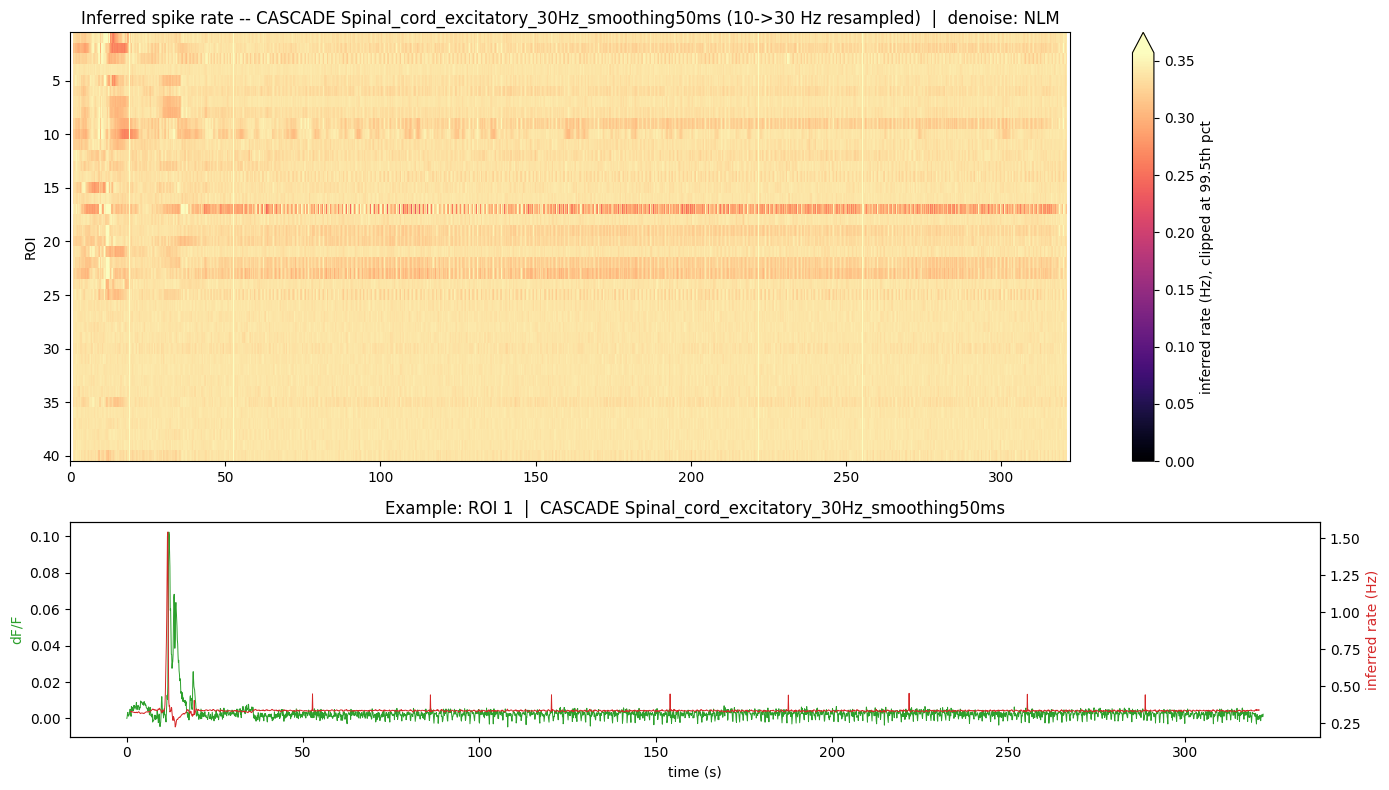

In [163]:
# Linear colour scale, but the single largest bin is a far outlier -- using it as vmax would
# push ~all pixels to the bottom (near-black) of the colormap. So clip the TOP of the scale
# to a high percentile (tune HEAT_CLIP_PCT); the few larger bins just saturate at full colour.
HEAT_CLIP_PCT = 99.5
finite = spike_rates[np.isfinite(spike_rates)]
vmax = float(np.percentile(finite, HEAT_CLIP_PCT)) if finite.size else 1.0
if vmax <= 0:                                          # degenerate (all-equal) fallback
    vmax = float(finite.max()) if finite.size else 1.0

fig, (ax_h, ax_ex) = plt.subplots(2, 1, figsize=(14, 8), height_ratios=[2, 1])
im = ax_h.imshow(np.ma.masked_invalid(spike_rates), aspect="auto", interpolation="nearest",
                 cmap="magma", vmin=0.0, vmax=vmax,
                 extent=[t_native[0], t_native[-1], len(roi_names) + 0.5, 0.5])
fig.colorbar(im, ax=ax_h, extend="max",
             label=f"inferred rate (Hz), clipped at {HEAT_CLIP_PCT}th pct")
ax_h.set_ylabel("ROI")
ax_h.set_title(f"Inferred spike rate -- CASCADE {CASCADE_MODEL_NAME} "
               f"(10->30 Hz resampled)  |  denoise: {METHOD_LABEL}")

ax_ex.plot(t_native, dff_active[:, 0], color="tab:green", lw=0.7)
ax_ex.set_ylabel("dF/F", color="tab:green"); ax_ex.set_xlabel("time (s)")
ax_r = ax_ex.twinx()
ax_r.plot(t_native, spike_rates[0], color="tab:red", lw=0.7)
ax_r.set_ylabel("inferred rate (Hz)", color="tab:red")
ax_ex.set_title(f"Example: {roi_names[0]}  |  CASCADE {CASCADE_MODEL_NAME}")
fig.tight_layout(); save_fig(fig, f"4_cascade_spike_rate_{DENOISE_METHOD}"); plt.show()


### 4b. Provenance check — does the DS40 output mean what we think it means?

A units bug is invisible in a heatmap, so check it against a trace whose answer we control.
Two synthetic dF/F traces are built with a known number of GCaMP-like transients (N and 2N)
and pushed through the same bridge. Two things must hold:

1. **Round-trip** — `sum(spikes_per_native_bin)` must equal `mean(rate_Hz) x duration`. This
   is the P0.1 relationship, checked end-to-end rather than by inspection.
2. **Linearity** — doubling the transients must roughly double the inferred total. A scale
   error that survives both is a *calibration* question, not a units question.

This does **not** validate absolute spike counts — CASCADE ties count to transient
amplitude, and the synthetic amplitude is arbitrary. It validates the plumbing.


In [164]:
RUN_CASCADE_PROVENANCE_CHECK = True   # cheap (2 short traces); cached like any other run


def synth_dff(n_events, n_t, rate_hz, amp=0.5, tau_s=0.6, sigma=0.02, seed=0):
    """Noisy trace with `n_events` evenly spaced exponential transients."""
    rng = np.random.default_rng(seed)
    trace = rng.normal(0.0, sigma, n_t)
    kern = amp * np.exp(-np.arange(0.0, 5 * tau_s, 1 / rate_hz) / tau_s)
    for onset in np.linspace(0.05, 0.92, n_events) * n_t:
        i = int(onset)
        trace[i:i + kern.size] += kern[: max(0, n_t - i)]
    return trace.astype(np.float32)


if RUN_CASCADE_PROVENANCE_CHECK:
    n_t, n_ev = 1200, 20                                  # 120 s at 10 Hz
    rate = 1.0 / native_bin_s
    t_synth = np.arange(n_t) / rate
    synth = np.vstack([synth_dff(n_ev, n_t, rate), synth_dff(2 * n_ev, n_t, rate, seed=1)])
    prov = run_cascade(synth, t_synth)

    dur = float(t_synth[-1] - t_synth[0])
    totals = np.nansum(prov["spikes_per_native_bin"], axis=1)
    mean_hz = np.nanmean(prov["spike_rate_native_hz"], axis=1)
    for k, n in enumerate([n_ev, 2 * n_ev]):
        print(f"  {n:2d} transients -> {totals[k]:6.1f} inferred spikes, "
              f"mean {mean_hz[k]:.3f} Hz, {totals[k] / n:.2f} spikes/transient")
    # 1) round-trip: total spikes must equal mean rate x duration (the P0.1 relationship)
    assert np.allclose(totals / dur, mean_hz, rtol=0.02), "rate/count round-trip broken"
    # 2) linearity: 2x the transients must give ~2x the inferred total
    ratio = totals[1] / totals[0]
    print(f"  linearity: 2N/N inferred-total ratio = {ratio:.2f} (expect ~2)")
    assert 1.5 <= ratio <= 2.5, f"non-linear response to transient count (ratio {ratio:.2f})"
    assert 0.01 <= mean_hz.max() <= 20, f"implausible inferred rate {mean_hz.max():.3f} Hz"
    print("  provenance OK: units round-trip and scale linearly.")


loading cached CASCADE prediction: cascade_ds40_37015e3d4236.npz
  20 transients ->  163.3 inferred spikes, mean 1.386 Hz, 8.17 spikes/transient
  40 transients ->  281.7 inferred spikes, mean 2.391 Hz, 7.04 spikes/transient
  linearity: 2N/N inferred-total ratio = 1.72 (expect ~2)
  provenance OK: units round-trip and scale linearly.


## 5. ROI correlation heatmaps

Pairwise Pearson correlation between ROIs, in natural ROI order (no reordering). A pair near
`r = 1` means those ROIs share a common signal — a real co-active network, or a field-wide
motion/illumination artifact worth inspecting.

- **5a** correlates the **dF/F** traces.
- **5b** correlates the **inferred (estimated) spike-rate** traces from §4.
- **5c** tests whether those two correlation structures actually differ.

### 5a. dF/F ROI correlation heatmap

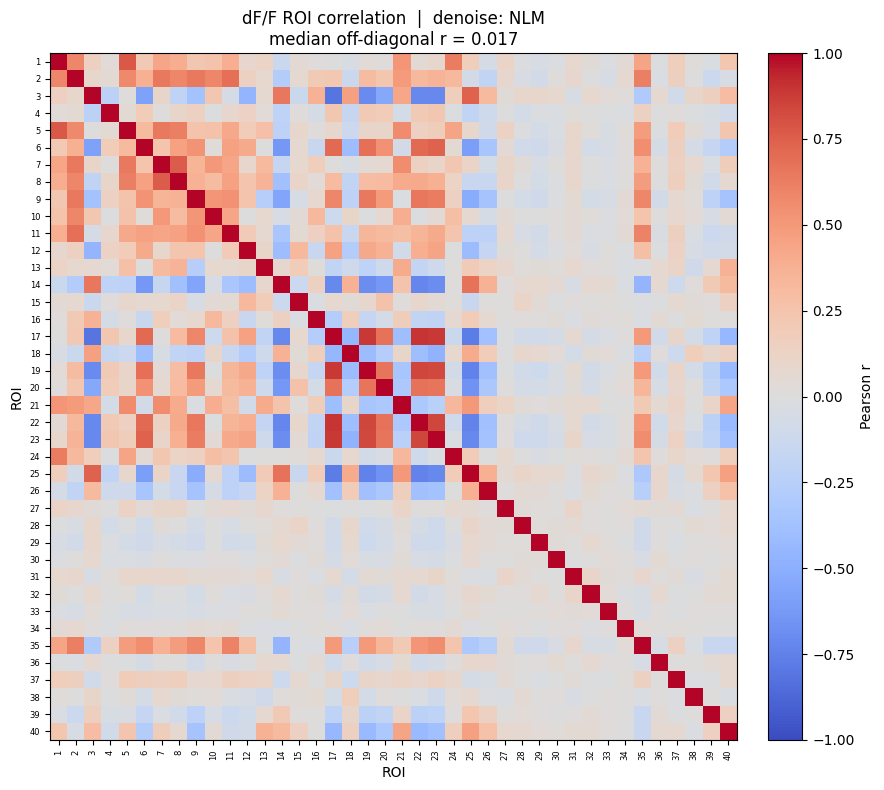

dF/F ROI correlation: median off-diagonal r = 0.017, max r = 0.898


In [165]:
def roi_corr_heatmap(traces, title, savename):
    """ROI x ROI Pearson correlation heatmap (natural ROI order).

    traces: (n_rois, n_time). Time bins with any non-finite value (e.g. CASCADE's
    edge padding) are dropped before correlating.
    """
    valid = np.isfinite(traces).all(axis=0)
    corr = np.corrcoef(traces[:, valid])
    iu = np.triu_indices(len(roi_names), 1)

    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Pearson r")
    ticks = range(len(roi_names))
    ax.set_xticks(ticks); ax.set_xticklabels([int(i) for i in roi_ids], fontsize=6, rotation=90)
    ax.set_yticks(ticks); ax.set_yticklabels([int(i) for i in roi_ids], fontsize=6)
    ax.set_xlabel("ROI"); ax.set_ylabel("ROI")
    ax.set_title(f"{title}  |  denoise: {METHOD_LABEL}\n"
                 f"median off-diagonal r = {np.median(corr[iu]):.3f}")
    fig.tight_layout(); save_fig(fig, savename); plt.show()
    print(f"{title}: median off-diagonal r = {np.median(corr[iu]):.3f}, max r = {corr[iu].max():.3f}")
    return corr


# 5a: correlation of the dF/F traces (dff is (n_frames, n_rois) -> transpose).
corr_dff = roi_corr_heatmap(dff_active.T, "dF/F ROI correlation", f"5a_dff_correlation_{DENOISE_METHOD}")

### 5b. Inferred spike-rate ROI correlation heatmap

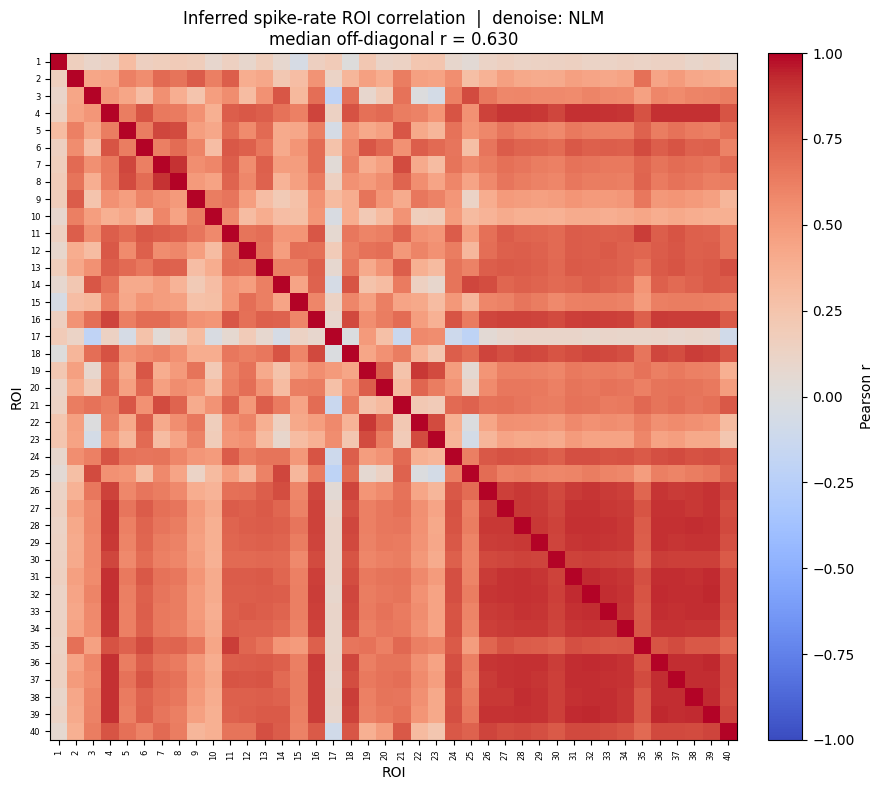

Inferred spike-rate ROI correlation: median off-diagonal r = 0.630, max r = 0.931


In [166]:
# 5b: correlation of the inferred (estimated) spike-rate traces from section 4.
# spike_rates is already (n_rois, n_frames); its NaN edge bins are dropped inside the helper.
corr_spikes = roi_corr_heatmap(
    spike_rates, "Inferred spike-rate ROI correlation", f"5b_spikerate_correlation_{DENOISE_METHOD}"
)

### 5c. Do the two correlation structures differ? (dF/F vs inferred spike rate)

Directly compares the 5a and 5b matrices to test whether ROIs relate differently once the
dF/F is turned into inferred spikes (spike inference sharpens transients and suppresses slow
shared drift, which can weaken or break apparent co-activity). Three complementary views:

- **Difference heatmap** `r(spike) − r(dF/F)` — red = a pair becomes *more* correlated after
  spike inference, blue = *less*; near-white = unchanged.
- **Scatter** of every pair's `r` in 5a vs 5b, against the `y = x` line — points off the line
  are pairs whose relationship changed. **Pearson** (linear) and **Spearman** (rank) quantify
  how well the two agree.
- **Mantel test** — a permutation test (shuffling ROI labels) that gives a valid p-value for
  the overall similarity of the two matrices, since the pairwise `r` values are not independent.

The printout also lists the RMS change, how many pairs flip sign, and the five pairs that move
the most.

**How to read this (P1.5).** `r(spike) − r(dF/F)` is best used as an **artifact detector**, not
as a standalone result. Slow shared drift — residual motion, bleaching, haemodynamics —
inflates dF/F correlation, and deconvolution suppresses exactly that; so pairs whose
correlation *collapses* after spike inference were probably sharing drift rather than
activity. The Mantel test answers whether the two *matrices* resemble each other overall; it
says nothing about whether any individual pair is significant. Per-pair significance, with a
null that preserves autocorrelation, is §8.

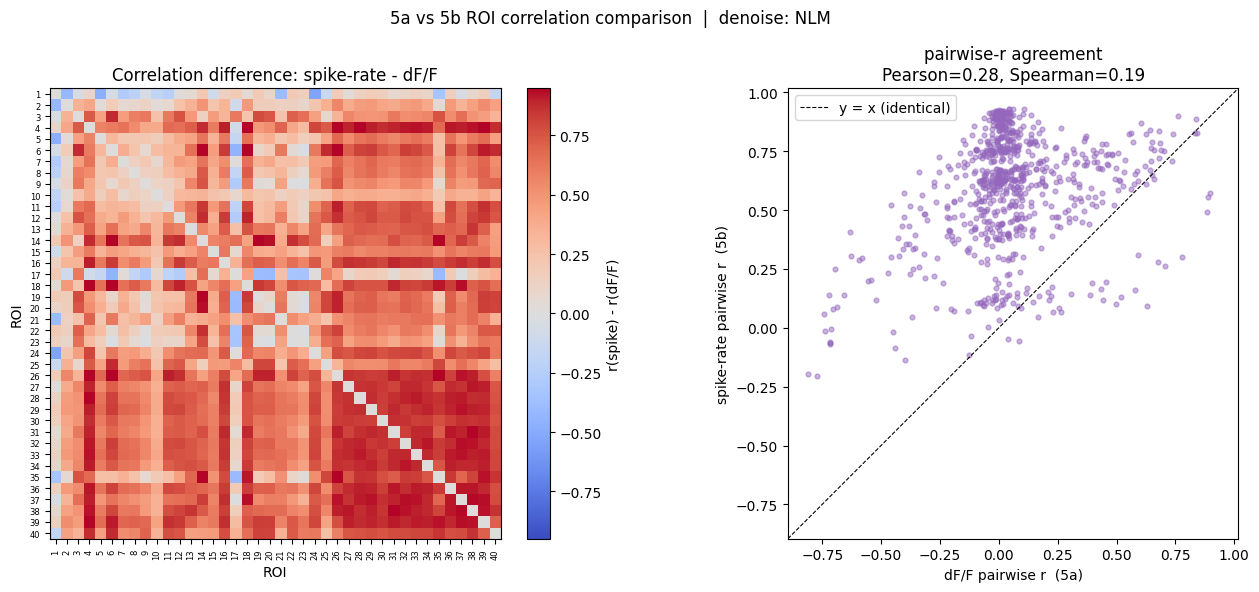

Agreement between the two correlation structures (n = 780 ROI pairs):
  Pearson  r   = 0.277  (p = 3.3e-15)
  Spearman rho = 0.191  (p = 8.1e-08)
  Mantel   r   = 0.277  (p = 0.0002, 5000 permutations)
  RMS difference = 0.613 r-units;  sign flips = 295/780 pairs
Most-changed ROI pairs (dF/F r -> spike-rate r):
  ROI 6-14: -0.63 -> +0.41  (delta = +1.04)
  ROI 6-26: -0.34 -> +0.66  (delta = +1.00)
  ROI 14-35: -0.46 -> +0.52  (delta = +0.98)
  ROI 26-35: -0.26 -> +0.72  (delta = +0.98)
  ROI 6-18: -0.40 -> +0.57  (delta = +0.98)


In [167]:
from scipy.stats import pearsonr, spearmanr

# The two ROI x ROI matrices to compare, as upper-triangle pairwise correlations.
iu = np.triu_indices(len(roi_names), 1)
r_dff = corr_dff[iu]        # dF/F pairwise r  (5a)
r_spk = corr_spikes[iu]     # spike-rate pairwise r  (5b)

# 1) Do the two sets of pairwise correlations agree? Pearson (linear) + Spearman (rank).
pear_r, pear_p = pearsonr(r_dff, r_spk)
spear_r, spear_p = spearmanr(r_dff, r_spk)


# 2) Mantel test: is the overall similarity of the two correlation matrices beyond chance?
#    The pairwise r's are not independent (they share ROIs), so an ordinary p-value is invalid.
#    Permuting ROI labels of one matrix keeps that dependence structure intact.
def _fastcorr(a, b):
    a = a - a.mean(); b = b - b.mean()
    return float((a * b).sum() / np.sqrt((a * a).sum() * (b * b).sum()))


def mantel_test(A, B, n_perm=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]
    tri = np.triu_indices(n, 1)
    a = A[tri]
    obs = _fastcorr(a, B[tri])
    ge = 1  # count the observed statistic itself
    for _ in range(n_perm):
        p = rng.permutation(n)
        if _fastcorr(a, B[np.ix_(p, p)][tri]) >= obs:
            ge += 1
    return obs, ge / (n_perm + 1)


mantel_r, mantel_p = mantel_test(corr_dff, corr_spikes, n_perm=5000)

# 3) Where do they differ? element-wise difference + which pairs move most.
diff = corr_spikes - corr_dff
np.fill_diagonal(diff, 0.0)
d = r_spk - r_dff
rms = float(np.sqrt(np.mean(d ** 2)))
n_flip = int(np.sum(np.sign(r_dff) != np.sign(r_spk)))

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15, 6))
vlim = float(np.percentile(np.abs(diff[iu]), 99)) or 1.0
im = ax0.imshow(diff, cmap="coolwarm", vmin=-vlim, vmax=vlim)
fig.colorbar(im, ax=ax0, fraction=0.046, pad=0.04, label="r(spike) - r(dF/F)")
ticks = range(len(roi_names))
ax0.set_xticks(ticks); ax0.set_xticklabels([int(i) for i in roi_ids], fontsize=6, rotation=90)
ax0.set_yticks(ticks); ax0.set_yticklabels([int(i) for i in roi_ids], fontsize=6)
ax0.set_xlabel("ROI"); ax0.set_ylabel("ROI")
ax0.set_title("Correlation difference: spike-rate - dF/F")

lo = min(r_dff.min(), r_spk.min()); hi = max(r_dff.max(), r_spk.max())
pad = 0.05 * (hi - lo + 1e-9)
ax1.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "k--", lw=0.8, label="y = x (identical)")
ax1.scatter(r_dff, r_spk, s=12, alpha=0.5, color="tab:purple")
ax1.set_xlim(lo - pad, hi + pad); ax1.set_ylim(lo - pad, hi + pad); ax1.set_aspect("equal")
ax1.set_xlabel("dF/F pairwise r  (5a)"); ax1.set_ylabel("spike-rate pairwise r  (5b)")
ax1.set_title(f"pairwise-r agreement\nPearson={pear_r:.2f}, Spearman={spear_r:.2f}")
ax1.legend(loc="upper left")
fig.suptitle(f"5a vs 5b ROI correlation comparison  |  denoise: {METHOD_LABEL}")
fig.tight_layout(); save_fig(fig, f"5c_corr_comparison_{DENOISE_METHOD}"); plt.show()

print(f"Agreement between the two correlation structures (n = {len(r_dff)} ROI pairs):")
print(f"  Pearson  r   = {pear_r:.3f}  (p = {pear_p:.1e})")
print(f"  Spearman rho = {spear_r:.3f}  (p = {spear_p:.1e})")
print(f"  Mantel   r   = {mantel_r:.3f}  (p = {mantel_p:.4f}, 5000 permutations)")
print(f"  RMS difference = {rms:.3f} r-units;  sign flips = {n_flip}/{len(d)} pairs")
top = np.argsort(-np.abs(d))[:5]
print("Most-changed ROI pairs (dF/F r -> spike-rate r):")
for k in top:
    i, j = iu[0][k], iu[1][k]
    print(f"  ROI {int(roi_ids[i])}-{int(roi_ids[j])}: {r_dff[k]:+.2f} -> {r_spk[k]:+.2f}  (delta = {d[k]:+.2f})")

### 5d. Background and blank regions as pseudo-ROIs

P0.5 requires `b(t)` to be entered into the correlation as an extra pseudo-ROI: if a term that
contains **no cell** tracks the real ROIs, the §5a structure is measuring the field, not the
network. The blank ROIs are the stronger version of the same test — they are real tissue
regions containing no soma, put through the identical pipeline.

Read the numbers, not the intent: a soma-free trace correlating with the cells at the same
order as the cells correlate with each other means most of §5a is a shared field term.


pseudo_ROI  r_to_mean_dFF  median_r_to_ROIs  max_r_to_ROIs
      b(t)       0.253893          0.086650       0.446934
   blank 0       0.211442          0.056282       0.474833
   blank 1       0.550072          0.085143       0.615103
   blank 2       0.295939          0.053869       0.540771

for reference, real ROI-to-ROI median r = 0.017


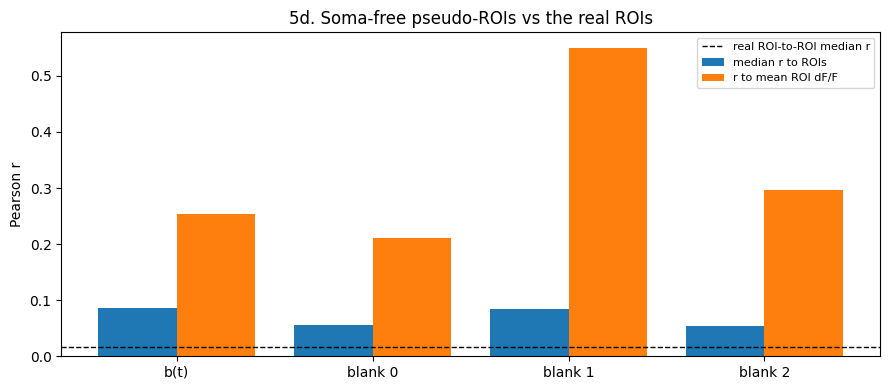

In [168]:
pseudo = {"b(t)": b_t, **{f"blank {k}": dff_blank[:, k] for k in range(dff_blank.shape[1])}}
mean_roi = np.nanmean(dff_active, axis=1)
rows = []
for name, trace in pseudo.items():
    rs = np.array([np.corrcoef(trace[frame_valid], dff_active[frame_valid, j])[0, 1]
                   for j in range(n_roi)])
    rows.append({"pseudo_ROI": name, "r_to_mean_dFF": float(np.corrcoef(trace[frame_valid],
                 mean_roi[frame_valid])[0, 1]), "median_r_to_ROIs": float(np.median(rs)),
                 "max_r_to_ROIs": float(np.max(rs))})
pseudo_df = pd.DataFrame(rows)
print(pseudo_df.to_string(index=False))
print(f"\nfor reference, real ROI-to-ROI median r = {np.median(corr_dff[np.triu_indices(n_roi, 1)]):.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(len(pseudo_df)) - 0.2, pseudo_df["median_r_to_ROIs"], 0.4, label="median r to ROIs")
ax.bar(np.arange(len(pseudo_df)) + 0.2, pseudo_df["r_to_mean_dFF"], 0.4, label="r to mean ROI dF/F")
ax.axhline(np.median(corr_dff[np.triu_indices(n_roi, 1)]), color="k", ls="--", lw=1,
           label="real ROI-to-ROI median r")
ax.set_xticks(range(len(pseudo_df))); ax.set_xticklabels(pseudo_df["pseudo_ROI"])
ax.set_ylabel("Pearson r"); ax.legend(fontsize=8)
ax.set_title("5d. Soma-free pseudo-ROIs vs the real ROIs")
fig.tight_layout(); save_fig(fig, "5d_pseudo_rois"); plt.show()


## 6. Event detection — with a false-positive rate you can quote

The pipeline previously jumped from dF/F straight to correlation with no event layer, which
is the core deliverable for a spontaneous-activity study. Events are runs where dF/F exceeds
`EVENT_THRESHOLD_K` x a robust per-ROI noise estimate for at least `EVENT_MIN_FRAMES`
consecutive frames.

**Choosing the threshold without ground truth.** CLAUDE.md §6 lists this as an open problem,
so instead of asserting a threshold we measure the error it produces: run the *identical*
detector on the **mirrored trace** (`−dF/F`). Nothing real goes down, so everything found
there is a false positive. Sweep the threshold until the negative-side count falls below 1%
of the positive-side count, and report **both** the chosen threshold and the residual
negative-side rate per ROI — that residual is a QC statistic in its own right, not just a
calibration by-product.

**Where this reasoning breaks.** It assumes noise is symmetric and that nothing real is
negative-going. Motion artifacts are bidirectional, so this must run *after* §1b — and a
negative-side rate that will not come down is evidence of **residual motion**, not a reason
to keep raising the threshold. Blank ROIs are run through the same detector: events there
are artifacts by construction.


chosen threshold: 2.00 x noise  (positive 4635, negative 15 events, blank 151 events/blank-ROI)
  ! the 1% target was already met at the LOWEST threshold swept, so the mirrored-trace
    criterion did not constrain the choice. Judge the threshold by the blank curve instead:
    a positive-going field-wide signal is invisible to a symmetric-noise test.


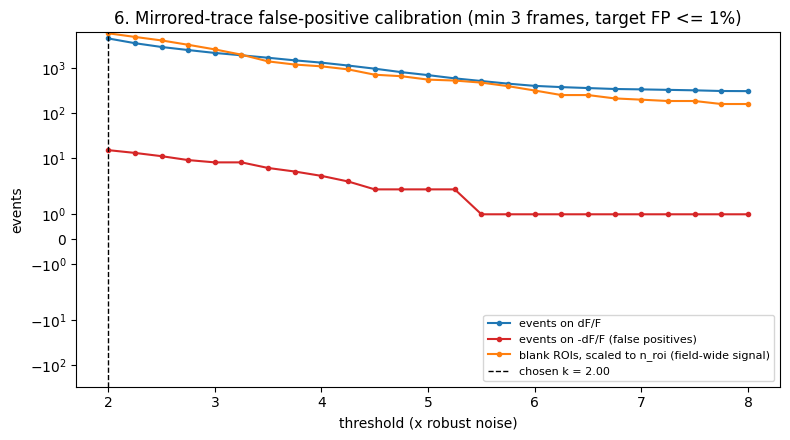

In [169]:
EVENT_MIN_FRAMES = 3          # >= 0.3 s at 10 Hz -- shorter runs are noise excursions
EVENT_SWEEP_K = np.arange(2.0, 8.01, 0.25)
EVENT_FP_TARGET = 0.01        # negative-side events must fall below 1% of positive-side


def noise_mad(x):
    """Robust per-sample noise from successive differences (immune to the events themselves)."""
    d = np.diff(x[np.isfinite(x)])
    return float(1.4826 * np.median(np.abs(d - np.median(d))) / np.sqrt(2))


def event_runs(x, thr_abs, min_frames=EVENT_MIN_FRAMES):
    """(start, stop) of contiguous runs above thr_abs. NaN (censored) never starts a run."""
    above = np.nan_to_num(x, nan=-np.inf) > thr_abs
    edge = np.diff(above.astype(np.int8), prepend=0, append=0)
    starts, stops = np.flatnonzero(edge == 1), np.flatnonzero(edge == -1)
    keep = (stops - starts) >= min_frames
    return starts[keep], stops[keep]


def count_events(traces, noise, k):
    return sum(event_runs(traces[:, j], k * noise[j])[0].size for j in range(traces.shape[1]))


event_noise = np.array([noise_mad(dff_corr[:, j]) for j in range(n_roi)])
blank_noise = np.array([noise_mad(dff_blank[:, k]) for k in range(dff_blank.shape[1])])
pos = np.array([count_events(dff_corr, event_noise, k) for k in EVENT_SWEEP_K])
neg = np.array([count_events(-dff_corr, event_noise, k) for k in EVENT_SWEEP_K])
# Per-ROI rate in soma-free tissue: the mirrored trace only catches SYMMETRIC noise, and a
# positive-going field-wide signal is exactly what it cannot see. The blanks can.
blank_rate = np.array([count_events(dff_blank, blank_noise, k) / dff_blank.shape[1]
                       for k in EVENT_SWEEP_K])
ratio = np.divide(neg, pos, out=np.full(pos.shape, np.inf, float), where=pos > 0)
ok = np.flatnonzero(ratio <= EVENT_FP_TARGET)
EVENT_THRESHOLD_K = float(EVENT_SWEEP_K[ok[0]]) if ok.size else float(EVENT_SWEEP_K[-1])
if not ok.size:
    print("! no threshold in the sweep reached the 1% false-positive target -- suspect "
          "residual motion (see 3g), not a threshold that needs raising further")
_sel = ok[0] if ok.size else -1
print(f"chosen threshold: {EVENT_THRESHOLD_K:.2f} x noise  (positive {pos[_sel]}, "
      f"negative {neg[_sel]} events, blank {blank_rate[_sel]:.0f} events/blank-ROI)")
if ok.size and ok[0] == 0:
    print("  ! the 1% target was already met at the LOWEST threshold swept, so the mirrored-"
          "trace\n    criterion did not constrain the choice. Judge the threshold by the blank "
          "curve instead:\n    a positive-going field-wide signal is invisible to a "
          "symmetric-noise test.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(EVENT_SWEEP_K, pos, "o-", ms=3, label="events on dF/F")
ax.plot(EVENT_SWEEP_K, neg, "o-", ms=3, color="tab:red", label="events on -dF/F (false positives)")
ax.plot(EVENT_SWEEP_K, blank_rate * n_roi, "o-", ms=3, color="tab:orange",
        label="blank ROIs, scaled to n_roi (field-wide signal)")
ax.axvline(EVENT_THRESHOLD_K, color="k", ls="--", lw=1,
           label=f"chosen k = {EVENT_THRESHOLD_K:.2f}")
ax.set_yscale("symlog"); ax.set_xlabel("threshold (x robust noise)"); ax.set_ylabel("events")
ax.set_title(f"6. Mirrored-trace false-positive calibration "
             f"(min {EVENT_MIN_FRAMES} frames, target FP <= {EVENT_FP_TARGET:.0%})")
ax.legend(fontsize=8)
fig.tight_layout(); save_fig(fig, "6_event_threshold_calibration"); plt.show()


In [170]:
_dt = float(np.median(np.diff(times_s)))


def detect_events(trace, noise):
    """Per-event amplitude, duration and decay tau for one ROI."""
    starts, stops = event_runs(trace, EVENT_THRESHOLD_K * noise)
    rows = []
    for s, e in zip(starts, stops):
        seg = trace[s:e]
        peak_i = s + int(np.nanargmax(seg))
        peak = float(trace[peak_i])
        tail = trace[peak_i:]
        below = np.flatnonzero(np.nan_to_num(tail, nan=-np.inf) < peak / np.e)
        rows.append({"onset_frame": int(s), "t_onset_s": float(times_s[s]),
                     "amplitude_dff": peak, "duration_s": (e - s) * _dt,
                     "decay_tau_s": float(below[0] * _dt) if below.size else np.nan})
    return rows


records = []
for j in range(n_roi):
    for r in detect_events(dff_corr[:, j], event_noise[j]):
        records.append({"roi": int(roi_ids[j]), **r})
events_df = pd.DataFrame(records)

dur_min = (times_s[-1] - times_s[0]) / 60.0
n_events = np.array([int((events_df["roi"] == int(roi_ids[j])).sum()) for j in range(n_roi)])
event_rate = n_events / dur_min
# The same detector on the mirrored trace and on the blank ROIs -- the two negative controls.
fp_per_roi = np.array([event_runs(-dff_corr[:, j], EVENT_THRESHOLD_K * event_noise[j])[0].size
                       for j in range(n_roi)]) / dur_min
blank_noise = np.array([noise_mad(dff_blank[:, k]) for k in range(dff_blank.shape[1])])
blank_events = np.array([event_runs(dff_blank[:, k], EVENT_THRESHOLD_K * blank_noise[k])[0].size
                         for k in range(dff_blank.shape[1])])

print(f"{len(events_df)} events over {dur_min:.1f} min; "
      f"{(n_events > 0).sum()}/{n_roi} ROIs active ({100 * (n_events > 0).mean():.0f}%)")
print(f"event rate: median {np.median(event_rate):.2f}/min, max {event_rate.max():.2f}/min")
print(f"residual false-positive rate: median {np.median(fp_per_roi):.3f}/min, "
      f"max {fp_per_roi.max():.3f}/min")
print(f"BLANK CONTROLS: {blank_events.tolist()} events "
      f"({'clean' if blank_events.sum() == 0 else 'NOT CLEAN -- artifact evidence, report it'})")


4635 events over 5.4 min; 40/40 ROIs active (100%)
event rate: median 15.64/min, max 49.72/min
residual false-positive rate: median 0.000/min, max 0.372/min
BLANK CONTROLS: [127, 182, 144] events (NOT CLEAN -- artifact evidence, report it)


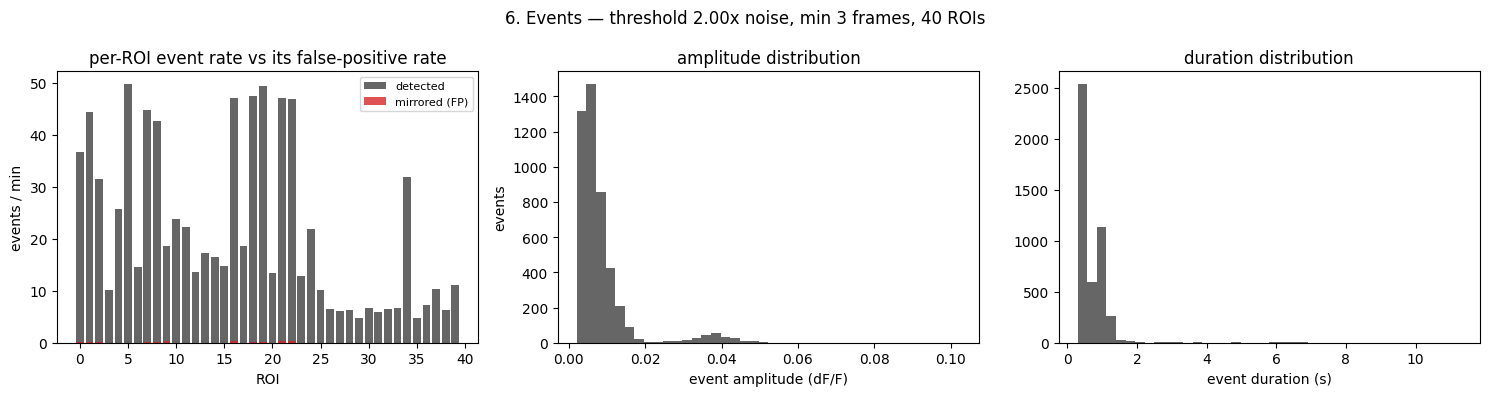

In [171]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(range(n_roi), event_rate, color="0.4", label="detected")
axes[0].bar(range(n_roi), fp_per_roi, color="tab:red", alpha=0.8, label="mirrored (FP)")
axes[0].set_xlabel("ROI"); axes[0].set_ylabel("events / min"); axes[0].legend(fontsize=8)
axes[0].set_title("per-ROI event rate vs its false-positive rate")
if len(events_df):
    axes[1].hist(events_df["amplitude_dff"], bins=40, color="0.4")
    axes[1].set_xlabel("event amplitude (dF/F)"); axes[1].set_ylabel("events")
    axes[2].hist(events_df["duration_s"], bins=40, color="0.4")
    axes[2].set_xlabel("event duration (s)")
axes[1].set_title("amplitude distribution"); axes[2].set_title("duration distribution")
fig.suptitle(f"6. Events — threshold {EVENT_THRESHOLD_K:.2f}x noise, "
             f"min {EVENT_MIN_FRAMES} frames, {n_roi} ROIs")
fig.tight_layout(); save_fig(fig, "6_event_summary"); plt.show()


## 7. ROI QC table, preserved traces, and the run manifest

One row per ROI in `main_output/roi_qc.csv`, every trace level in `main_output/traces.npz`,
and every parameter in `main_output/run_manifest.yaml`. These are small text/array files and
are written **regardless of `SAVE_OUTPUTS`** — that flag governs figures and the movie, not
the record of what was computed.

- **`noise_nu`** is the CASCADE noise metric, `median(|dF/F[t+1] − dF/F[t]|) / sqrt(rate)` in
  %·Hz^-1/2, computed on the **native-rate** trace (computing it after upsampling would make
  adjacent samples artificially similar and understate the noise).
- **`saturated_ever`** is exact and free: the max projection is the pixelwise max over every
  frame, so if no pixel in an ROI reaches the detector ceiling there, that ROI never
  saturated. CLAUDE.md flags saturation as a failure mode shared by *every* inference method.
  `saturated_pixel_frac` is estimated on a subsample of frames.
- **`F0` is computed from raw, pre-correction F.** A dim ROI whose F0 approaches zero can
  produce dF/F in the thousands through `np.clip(f0, 1e-3, None)` and would sail into CASCADE
  unchecked. On this recording that is a *latent* risk, not an active one (per-ROI mean F is
  80–578), but the gate belongs here.

`pass` is the conjunction of all gates; every figure from here on states how many ROIs passed.


In [172]:
QC_F0_MIN_NOISE_MULT = 5      # F0 must exceed this multiple of the raw-F noise
QC_MIN_ANNULUS_PX = 50        # below this the neuropil estimate is too noisy to trust
QC_SAT_SUBSAMPLE = 200        # frames sampled for saturated_pixel_frac

_raw_max = int(max_proj.max())
DETECTOR_MAX = next(m for m in (4095, 16383, 65535) if _raw_max <= m)
_sat_idx = np.linspace(0, n_frames - 1, QC_SAT_SUBSAMPLE).astype(int)
_sat_hits = np.zeros(n_roi)
for i in _sat_idx:
    flat = load_frame(int(i)).ravel()
    for j, m in enumerate(roi_masks):
        _sat_hits[j] += float(flat[np.flatnonzero(m.ravel())].max() >= DETECTOR_MAX)

_rate = 1.0 / _dt
nu = np.array([100 * np.median(np.abs(np.diff(dff_corr[np.isfinite(dff_corr[:, j]), j])))
               / np.sqrt(_rate) for j in range(n_roi)])
areas = np.array([int(m.sum()) for m in roi_masks])
cents = np.array([[np.nonzero(m)[1].mean(), np.nonzero(m)[0].mean()] for m in roi_masks])
F0_med = np.median(F0_raw, axis=0)
F_noise = np.array([noise_mad(F_roi[:, j]) for j in range(n_roi)])
sat_ever = np.array([max_proj[m].max() >= DETECTOR_MAX for m in roi_masks])

qc = pd.DataFrame({
    "roi_id": roi_ids.astype(int), "area_px": areas,
    "area_um2": areas * pixel_um ** 2,
    "equiv_diameter_um": 2 * np.sqrt(areas / np.pi) * pixel_um,
    "centroid_x": cents[:, 0], "centroid_y": cents[:, 1],
    "mean_F_raw": F_roi.mean(axis=0), "F0": F0_med, "noise_nu": nu,
    "snr": np.array([np.nanmax(dff_corr[:, j]) for j in range(n_roi)]) / (nu / 100 * np.sqrt(_rate)),
    "saturated_ever": sat_ever, "saturated_pixel_frac": _sat_hits / QC_SAT_SUBSAMPLE,
    "motion_r": np.abs(motion_r[:n_roi]).max(axis=1),
    "motion_flagged": (motion_p[:n_roi] < 0.05).any(axis=1),
    "neuropil_alpha_est": alpha_est, "annulus_px": annulus_px,
    "n_events": n_events, "event_rate_per_min": event_rate,
    "fp_rate_per_min": fp_per_roi,
})
fail = {
    "F0_too_dim": qc["F0"] < QC_F0_MIN_NOISE_MULT * F_noise,
    "thin_annulus": qc["annulus_px"] < QC_MIN_ANNULUS_PX,
    "saturated": qc["saturated_ever"],
    "motion_coupled": qc["motion_flagged"],
}
qc["fail_reason"] = ["; ".join(k for k, v in fail.items() if v[i]) for i in range(n_roi)]
qc["pass"] = qc["fail_reason"] == ""
roi_pass = qc["pass"].to_numpy()

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
qc.to_csv(OUTPUT_DIR / "roi_qc.csv", index=False)
print(f"{roi_pass.sum()}/{n_roi} ROIs pass QC -> {OUTPUT_DIR / 'roi_qc.csv'}")
for k, v in fail.items():
    print(f"  {k}: {int(np.sum(v))}")


40/40 ROIs pass QC -> main_output/roi_qc.csv
  F0_too_dim: 0
  thin_annulus: 0
  saturated: 0
  motion_coupled: 0


In [173]:
import importlib.metadata as _md
import subprocess as _sp

np.savez_compressed(
    OUTPUT_DIR / "traces.npz",
    F_roi=F_roi, F_neuropil=F_neuropil, F_corr=F_corr, F_blank=F_blank, F0_raw=F0_raw,
    dFF=dff_corr, dFF_blank=dff_blank, b_t=b_t, frame_valid=frame_valid, times_s=times_s,
    shifts=shifts, roi_ids=roi_ids, roi_pass=roi_pass, spike_rates=spike_rates,
)


def _git_hash():
    try:
        return _sp.run(["git", "rev-parse", "HEAD"], capture_output=True, text=True,
                       cwd=Path.cwd()).stdout.strip() or None
    except Exception:
        return None


manifest = {
    "recording": {"data_dir": str(DATA_DIR), "channel": CHANNEL, "modality": MODALITY,
                  "n_frames": int(n_frames), "duration_s": float(times_s[-1]),
                  "rate_hz": float(_rate), "pixel_size_um": pixel_um,
                  "exposure_ms": exposure_ms, "objective_mag": objective_mag,
                  "indicator": INDICATOR, "detector_max": int(DETECTOR_MAX)},
    "rois": {"label_tiff": str(ROI_LABEL_PATH), "n_rois": int(n_roi),
             "n_pass": int(roi_pass.sum()), "n_blank": int(dff_blank.shape[1])},
    "preprocess": {"legacy_pipeline": LEGACY_PIPELINE, "trace_denoise": TRACE_DENOISE,
                   "display_denoise": DENOISE_METHOD, "background_mode": BACKGROUND_MODE,
                   "background_percentile": BACKGROUND_PERCENTILE,
                   "motion_correction": USE_MOTION_CORRECTION,
                   "motion_max_shift_frac": MOTION_MAX_SHIFT_FRAC,
                   "frames_censored": int((~frame_valid).sum())},
    "neuropil": {"r_in_um": NEUROPIL_R_IN_UM, "r_out_um": NEUROPIL_R_OUT_UM,
                 "alpha_mode": NEUROPIL_ALPHA_MODE, "alpha_fixed": NEUROPIL_ALPHA,
                 "alpha_used_median": float(np.median(alpha_used)),
                 "alpha_est_median": float(np.median(alpha_est))},
    "dff": {"baseline_percentile": BASELINE_PERCENTILE, "baseline_window_s": BASELINE_WINDOW_S},
    "events": {"threshold_k": EVENT_THRESHOLD_K, "min_frames": EVENT_MIN_FRAMES,
               "fp_target": EVENT_FP_TARGET, "n_events": int(len(events_df)),
               "blank_events": blank_events.tolist()},
    "cascade": {"model": CASCADE_MODEL_NAME, "model_rate_hz": float(casc["model_rate_hz"]),
                "native_rate_hz": float(casc["native_rate_hz"])},
    "environment": {"git_hash": _git_hash(),
                    "packages": {p: _md.version(p) for p in
                                 ("numpy", "scipy", "scikit-image", "pandas", "matplotlib")}},
}
with open(OUTPUT_DIR / "run_manifest.yaml", "w") as fh:
    yaml.safe_dump(manifest, fh, sort_keys=False, default_flow_style=False)
print(f"wrote {OUTPUT_DIR / 'traces.npz'} and {OUTPUT_DIR / 'run_manifest.yaml'}")
print(f"  git {manifest['environment']['git_hash']}  |  {roi_pass.sum()}/{n_roi} ROIs pass QC")


wrote main_output/traces.npz and main_output/run_manifest.yaml
  git 5e52883eb6be8fb9b7f8a2edebfaa2714520a891  |  40/40 ROIs pass QC


## 8. Is the correlation structure real? Nulls, CIs, and a confound waterfall

§5 reports Pearson r with no reference point. Calcium traces are strongly autocorrelated, so
the ordinary p-value on r is severely anti-conservative — with 3220 samples it will call
almost any pair significant. Two things fix that, and both are needed:

**A null that preserves autocorrelation.** `pair_xcorr()` computes the *circular* cross-
correlation of every ROI pair at every lag in one FFT. Lag 0 is the observed r; the remaining
lags (beyond a few autocorrelation times, where the traces are effectively decoupled) are the
null distribution. One transform gives both the null for §8 and the lag structure for §9.

**Confidence intervals that respect blocks.** A circular *block* bootstrap resamples runs of
length ≥ several autocorrelation times, applying the same block draw to every ROI so the
cross-ROI structure survives.

**The waterfall** then removes each candidate confound from the traces — residual motion,
`b(t)`, per-ROI neuropil — one at a time and jointly, and reports the median off-diagonal r
at each stage. Anything that survives all of them is what the recording actually supports.
Per-pair p-values get Benjamini–Hochberg FDR across all pairs.

Censored frames are **dropped**, not interpolated, before any of this.


In [174]:
def acf_time(x, max_lag=400):
    """Lag (frames) at which the autocorrelation first falls below 1/e."""
    x = x[np.isfinite(x)]
    x = x - x.mean()
    ac = np.correlate(x, x, "full")[x.size - 1:x.size - 1 + max_lag]
    ac = ac / ac[0]
    below = np.flatnonzero(ac < 1 / np.e)
    return int(below[0]) if below.size else max_lag


def pair_xcorr(X):
    """(n_pairs, n_time) circular cross-correlation r at every lag, plus the pair indices.

    Lag 0 is the ordinary Pearson r. Far lags are a null that keeps each trace's own
    autocorrelation intact -- an i.i.d. shuffle would not.
    """
    Z = (X - X.mean(0)) / np.where(X.std(0) > 0, X.std(0), 1)
    n = X.shape[0]
    F = np.fft.rfft(Z, axis=0)
    iu = np.triu_indices(X.shape[1], 1)
    out = np.empty((iu[0].size, n))
    for k, (i, j) in enumerate(zip(*iu)):
        out[k] = np.fft.irfft(F[:, i] * np.conj(F[:, j]), n) / n
    return out, iu


def pair_stats(X, null_gap=None):
    """Observed r and a circular-shift p-value for every ROI pair."""
    xc, iu = pair_xcorr(X)
    n = X.shape[0]
    gap = null_gap or 5 * int(np.median([acf_time(X[:, j]) for j in range(X.shape[1])]))
    lags = np.fft.fftfreq(n, 1 / n).astype(int)
    far = np.abs(lags) > gap
    r0 = xc[:, 0]
    p = (np.abs(xc[:, far]) >= np.abs(r0)[:, None]).mean(axis=1)
    return r0, p, iu, xc


def bh_fdr(p, q=0.05):
    """Benjamini-Hochberg: boolean mask of the hypotheses that survive at level q."""
    order = np.argsort(p)
    m = p.size
    passed = np.asarray(p)[order] <= q * (np.arange(1, m + 1) / m)
    k = np.flatnonzero(passed)
    return np.asarray(p) <= (np.asarray(p)[order][k[-1]] if k.size else -1)


def block_bootstrap(X, stat, n_boot=400, block=None, seed=0):
    """Circular block bootstrap. The same block draw is applied to every ROI, so the
    cross-ROI structure that we are estimating is preserved."""
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    block = block or max(10, 3 * int(np.median([acf_time(X[:, j]) for j in range(X.shape[1])])))
    vals = np.empty(n_boot)
    for b in range(n_boot):
        starts = rng.integers(0, n, int(np.ceil(n / block)))
        idx = np.concatenate([(s + np.arange(block)) % n for s in starts])[:n]
        vals[b] = stat(X[idx])
    return vals


def median_offdiag(X):
    c = np.corrcoef(X.T)
    return float(np.median(c[np.triu_indices(X.shape[1], 1)]))


confound waterfall on 40/40 QC-passing ROIs, 3220/3220 frames
        stage  median_r    ci_lo    ci_hi  pairs_surviving_FDR  n_pairs
     raw dF/F  0.016600 0.013908 0.028017                  465      780
     - motion  0.016672 0.013871 0.028030                  465      780
       - b(t)  0.012011 0.007531 0.018741                  476      780
 - blank ROIs  0.014844 0.010910 0.021759                  420      780
   - neuropil  0.011519 0.007005 0.019503                  485      780
- all jointly  0.009013 0.006719 0.017133                  436      780


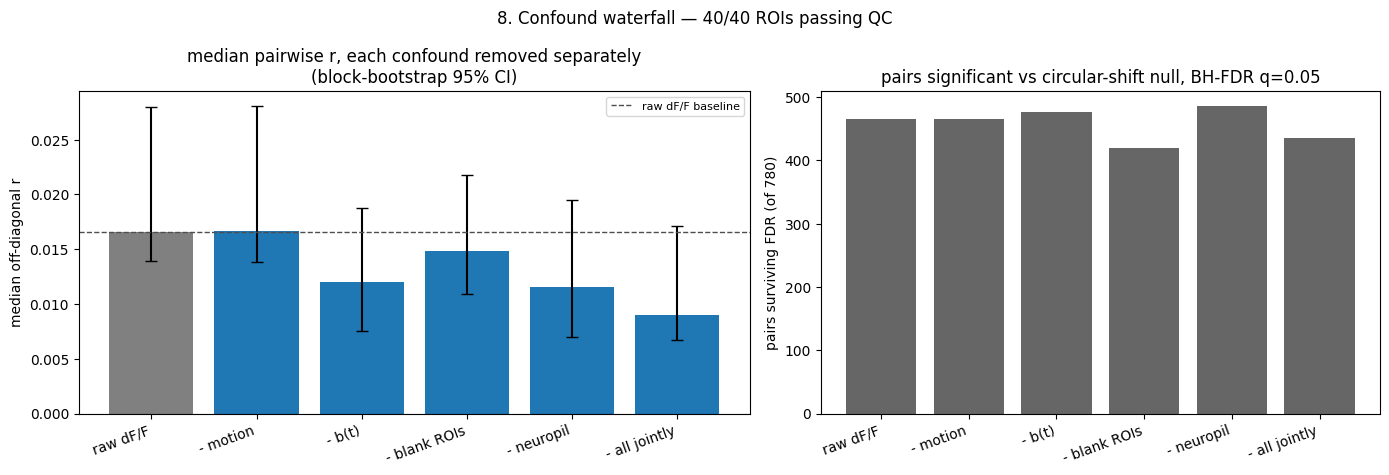

In [175]:
def residualize(X, C):
    """Least-squares residuals of every column of X after regressing on C (+ intercept)."""
    C1 = np.column_stack([np.ones(len(C)), np.asarray(C, dtype=float).reshape(len(C), -1)])
    return X - C1 @ np.linalg.lstsq(C1, X, rcond=None)[0]


_keep = frame_valid & np.isfinite(dff_corr).all(axis=1)
X0 = dff_corr[_keep][:, roi_pass]
_motion = np.column_stack([shifts[_keep, 1], shifts[_keep, 0], shift_mag[_keep]])
_bg = b_t[_keep, None]
_np_traces = F_neuropil[_keep][:, roi_pass]

_blanks = dff_blank[_keep]
_slopes = np.array([np.polyfit(_np_traces[:, j], X0[:, j], 1)[0] for j in range(X0.shape[1])])
_np_removed = X0 - _np_traces * _slopes

stages = {
    "raw dF/F": X0,
    "- motion": residualize(X0, _motion),
    "- b(t)": residualize(X0, _bg),
    "- blank ROIs": residualize(X0, _blanks),
    "- neuropil": _np_removed,
    "- all jointly": residualize(_np_removed, np.column_stack([_motion, _bg, _blanks])),
}

rows = []
for name, Xs in stages.items():
    r0, p, iu, _ = pair_stats(Xs)
    boot = block_bootstrap(Xs, median_offdiag)
    rows.append({"stage": name, "median_r": float(np.median(r0)),
                 "ci_lo": float(np.percentile(boot, 2.5)), "ci_hi": float(np.percentile(boot, 97.5)),
                 "pairs_surviving_FDR": int(bh_fdr(p).sum()), "n_pairs": int(r0.size)})
waterfall = pd.DataFrame(rows)
print(f"confound waterfall on {int(roi_pass.sum())}/{n_roi} QC-passing ROIs, "
      f"{_keep.sum()}/{n_frames} frames")
print(waterfall.to_string(index=False))

fig, (axl, axr) = plt.subplots(1, 2, figsize=(14, 4.8), width_ratios=[1.2, 1])
xs = np.arange(len(waterfall))
# Bars, not a line: every stage except the last removes ONE confound from the raw traces, so
# they are independent comparisons against the same baseline. A connected line would read as
# a cumulative sequence, which these are not.
axl.bar(xs, waterfall["median_r"],
        yerr=[waterfall["median_r"] - waterfall["ci_lo"],
              waterfall["ci_hi"] - waterfall["median_r"]],
        capsize=4, color=["0.5"] + ["tab:blue"] * (len(xs) - 1))
axl.axhline(waterfall["median_r"][0], color="0.3", lw=1, ls="--", label="raw dF/F baseline")
axl.axhline(0, color="k", lw=0.8, ls=":")
axl.legend(fontsize=8)
axl.set_xticks(xs); axl.set_xticklabels(waterfall["stage"], rotation=20, ha="right")
axl.set_ylabel("median off-diagonal r")
axl.set_title("median pairwise r, each confound removed separately\n(block-bootstrap 95% CI)")
axr.bar(xs, waterfall["pairs_surviving_FDR"], color="0.4")
axr.set_xticks(xs); axr.set_xticklabels(waterfall["stage"], rotation=20, ha="right")
axr.set_ylabel(f"pairs surviving FDR (of {waterfall['n_pairs'][0]})")
axr.set_title("pairs significant vs circular-shift null, BH-FDR q=0.05")
fig.suptitle(f"8. Confound waterfall — {int(roi_pass.sum())}/{n_roi} ROIs passing QC")
fig.tight_layout(); save_fig(fig, "8_confound_waterfall"); plt.show()


## 9. Correlation vs distance and vs lag — artifact or network?

Two geometries separate optical/motion crosstalk from real coupling, and neither is visible
in the §5 heatmap:

- **r vs distance.** Blur, out-of-focus light and residual translation all couple *nearby*
  ROIs preferentially, so they produce r that decays monotonically with centroid distance.
- **r vs lag.** Shared optical or motion artifact arrives everywhere at once, so its
  cross-correlogram peaks sharply at lag 0 for essentially every pair.

**The reading rule:** a peak-lag distribution overwhelmingly at zero *combined with* monotone
decay of r with distance indicates crosstalk. A spread of non-zero lags is a candidate for
real coupling — DRG cross-excitation after nerve injury is an established phenomenon — and is
not explainable by a shared optical term. This distinguishes artifact from network far better
than the §5c Mantel test, which only asks whether two matrices resemble each other.

Run on both dF/F and the detected event trains; the null band is the far-lag distribution
from the same FFT.


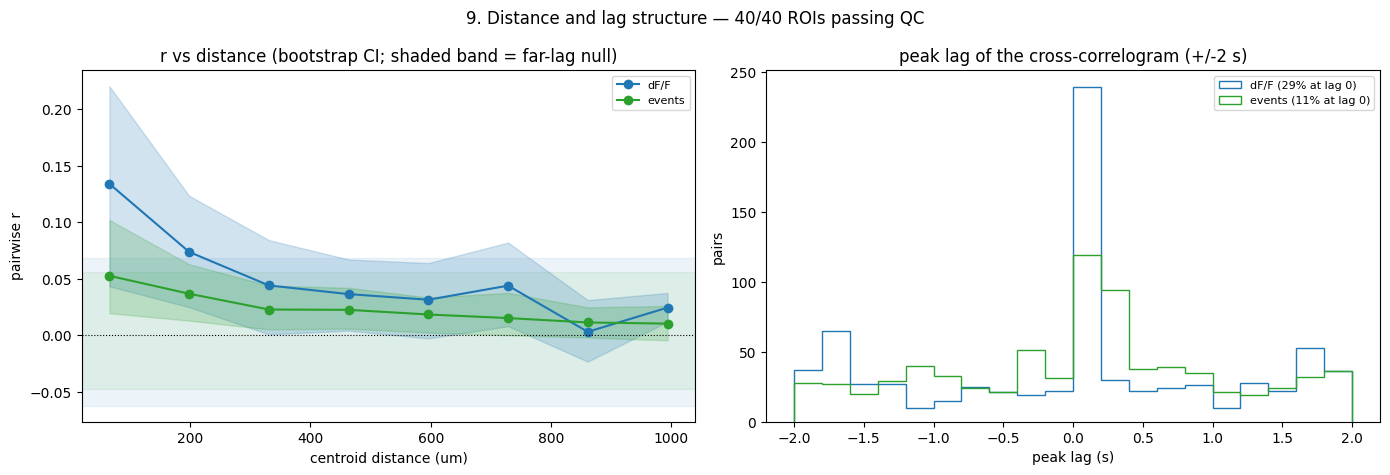

dF/F: 29.2% of pairs peak at lag 0; r vs distance slope -1.17e-04 per um
events: 10.5% of pairs peak at lag 0; r vs distance slope -4.80e-05 per um


In [176]:
LAG_WINDOW_S = 2.0
_pass_idx = np.flatnonzero(roi_pass)
_cent_um = cents[_pass_idx] * pixel_um
_dist = np.hypot(_cent_um[:, None, 0] - _cent_um[None, :, 0],
                 _cent_um[:, None, 1] - _cent_um[None, :, 1])

_ev = np.zeros((n_frames, n_roi), dtype=np.float32)
for _, row in events_df.iterrows():
    _ev[int(row["onset_frame"]), int(np.flatnonzero(roi_ids == row["roi"])[0])] = 1.0
_ev = np.apply_along_axis(np.convolve, 0, _ev, np.ones(3), mode="same")

_n = int(_keep.sum())
_lags = np.fft.fftfreq(_n, 1 / _n).astype(int)
_near = np.abs(_lags) <= int(round(LAG_WINDOW_S / _dt))
_far = np.abs(_lags) > 5 * int(np.median([acf_time(X0[:, j]) for j in range(X0.shape[1])]))

series = {"dF/F": dff_corr[_keep][:, roi_pass], "events": _ev[_keep][:, roi_pass]}
xcs, peak_lags = {}, {}
for name, X in series.items():
    xc, iu = pair_xcorr(X)
    xcs[name] = xc
    win = xc[:, _near]
    peak_lags[name] = _lags[_near][np.argmax(win, axis=1)] * _dt
d_pairs = _dist[iu]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
bins = np.linspace(0, d_pairs.max(), 9)
which = np.digitize(d_pairs, bins) - 1
rng = np.random.default_rng(0)
for name, color in [("dF/F", "tab:blue"), ("events", "tab:green")]:
    r0 = xcs[name][:, 0]
    centers, mids, los, his = [], [], [], []
    for b in range(len(bins) - 1):
        sel = which == b
        if sel.sum() < 3:
            continue
        boot = [np.mean(rng.choice(r0[sel], sel.sum())) for _ in range(500)]
        centers.append(0.5 * (bins[b] + bins[b + 1])); mids.append(r0[sel].mean())
        los.append(np.percentile(boot, 2.5)); his.append(np.percentile(boot, 97.5))
    axes[0].plot(centers, mids, "o-", color=color, label=name)
    axes[0].fill_between(centers, los, his, color=color, alpha=0.2)
    null = xcs[name][:, _far]
    axes[0].axhspan(np.percentile(null, 2.5), np.percentile(null, 97.5), color=color, alpha=0.08)
    axes[1].hist(peak_lags[name], bins=np.arange(-LAG_WINDOW_S, LAG_WINDOW_S + _dt, 2 * _dt),
                 histtype="step", color=color, label=f"{name} ({np.mean(np.abs(peak_lags[name]) < 1e-9):.0%} at lag 0)")
axes[0].axhline(0, color="k", lw=0.8, ls=":")
axes[0].set_xlabel("centroid distance (um)"); axes[0].set_ylabel("pairwise r")
axes[0].set_title("r vs distance (bootstrap CI; shaded band = far-lag null)")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("peak lag (s)"); axes[1].set_ylabel("pairs")
axes[1].set_title(f"peak lag of the cross-correlogram (+/-{LAG_WINDOW_S:g} s)")
axes[1].legend(fontsize=8)
fig.suptitle(f"9. Distance and lag structure — {len(_pass_idx)}/{n_roi} ROIs passing QC")
fig.tight_layout(); save_fig(fig, "9_distance_and_lag"); plt.show()

for name in series:
    zero_frac = float(np.mean(np.abs(peak_lags[name]) < 1e-9))
    slope = np.polyfit(d_pairs, xcs[name][:, 0], 1)[0]
    print(f"{name}: {zero_frac:.1%} of pairs peak at lag 0; r vs distance slope "
          f"{slope:+.2e} per um")


## 10. Soma size vs activity — and the SNR control that has to come with it

ROI equivalent diameter is a coarse proxy for DRG cell class (small ≈ nociceptor, large ≈
proprioceptor/LTMR), which connects to the falsifiable prediction in CLAUDE.md §11.

**The control is mandatory, not optional.** A larger ROI averages more pixels, so its noise is
lower purely by construction — an apparent "large cells are more active" result can be pure
SNR. ν vs diameter is therefore plotted on the same figure, and the size–activity relationship
is reported *with ν partialled out* as well as raw. If ν varies systematically with diameter
and the relationship does not survive the partial, it should not be reported at all.

Size bins are a **proxy**, never a cell-type assignment — and a weaker proxy here than in a
sectioned image: without optical sectioning an ROI drawn on a widefield projection includes
out-of-focus contributions from above and below, so measured diameter overestimates soma size
by an unknown, depth-dependent amount.


diameter vs event rate:  rho = -0.30 (p = 0.057)
diameter vs noise nu:    rho = -0.78 (p = 0.000)   <- the SNR control
diameter vs event rate, nu partialled out: rho = +0.41


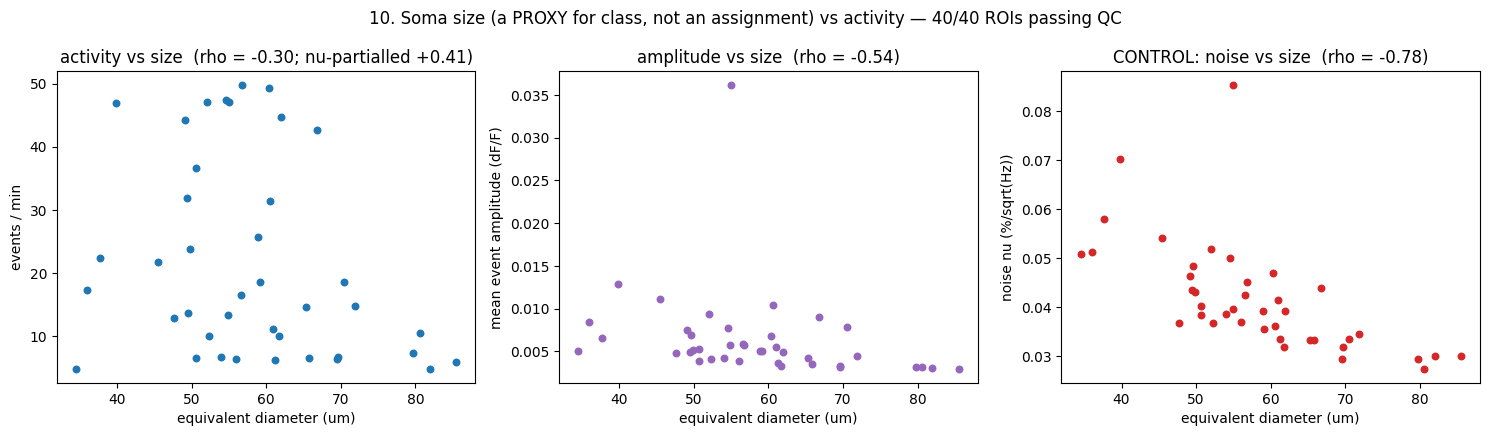

In [177]:
def spearman_partial(x, y, z):
    """Spearman correlation of x and y after linearly removing z from both (on ranks)."""
    from scipy.stats import rankdata
    rx, ry, rz = (rankdata(v) for v in (x, y, z))
    rz1 = np.column_stack([np.ones_like(rz), rz])
    ex = rx - rz1 @ np.linalg.lstsq(rz1, rx, rcond=None)[0]
    ey = ry - rz1 @ np.linalg.lstsq(rz1, ry, rcond=None)[0]
    return float(np.corrcoef(ex, ey)[0, 1])


q = qc[qc["pass"]]
diam, rate, nu_p = q["equiv_diameter_um"].to_numpy(), q["event_rate_per_min"].to_numpy(), q["noise_nu"].to_numpy()
amp = np.array([events_df.loc[events_df["roi"] == r, "amplitude_dff"].mean() if
                (events_df["roi"] == r).any() else np.nan for r in q["roi_id"]])

rho_rate, p_rate = spearmanr(diam, rate)
rho_nu, p_nu = spearmanr(diam, nu_p)
rho_amp, p_amp = spearmanr(diam[np.isfinite(amp)], amp[np.isfinite(amp)])
rho_partial = spearman_partial(diam, rate, nu_p)
print(f"diameter vs event rate:  rho = {rho_rate:+.2f} (p = {p_rate:.3f})")
print(f"diameter vs noise nu:    rho = {rho_nu:+.2f} (p = {p_nu:.3f})   <- the SNR control")
print(f"diameter vs event rate, nu partialled out: rho = {rho_partial:+.2f}")
if abs(rho_nu) > 0.3 and abs(rho_partial) < abs(rho_rate) / 2:
    print("  ! the size-activity relation largely disappears once nu is controlled -- "
          "report it as SNR, not biology")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].scatter(diam, rate, s=22, color="tab:blue")
axes[0].set_xlabel("equivalent diameter (um)"); axes[0].set_ylabel("events / min")
axes[0].set_title(f"activity vs size  (rho = {rho_rate:+.2f}; nu-partialled {rho_partial:+.2f})")
axes[1].scatter(diam[np.isfinite(amp)], amp[np.isfinite(amp)], s=22, color="tab:purple")
axes[1].set_xlabel("equivalent diameter (um)"); axes[1].set_ylabel("mean event amplitude (dF/F)")
axes[1].set_title(f"amplitude vs size  (rho = {rho_amp:+.2f})")
axes[2].scatter(diam, nu_p, s=22, color="tab:red")
axes[2].set_xlabel("equivalent diameter (um)"); axes[2].set_ylabel("noise nu (%/sqrt(Hz))")
axes[2].set_title(f"CONTROL: noise vs size  (rho = {rho_nu:+.2f})")
fig.suptitle(f"10. Soma size (a PROXY for class, not an assignment) vs activity — "
             f"{len(q)}/{n_roi} ROIs passing QC")
fig.tight_layout(); save_fig(fig, "10_size_vs_activity"); plt.show()


## 11. CASCADE vs OASIS vs the threshold detector

Three inference methods on the identical dF/F, compared by Jaccard overlap of event times at
±1 bin tolerance and by the correlation of per-ROI rates.

**Agreement here is weak evidence, and the direction of the weakness matters** (CLAUDE.md
§13). These methods share failure modes: indicator saturation makes all of them
underestimate high-frequency activity, and GCaMP8f use-dependent slowing makes single-kernel
deconvolution emit false positives after bursts. Two methods agreeing *during a burst* is
correlated error, not validation. What the comparison is actually good for is the opposite
signal — where the methods **disagree**, at least one is wrong, and those ROIs deserve a look.

OASIS is optional: if `oasis-deconv` is not installed in this kernel the section runs
CASCADE vs threshold only and says so.


! oasis not installed (pip install oasis-deconv in the Cajal env) -- running CASCADE vs threshold detector only
threshold (6) vs CASCADE: per-ROI rate rho = +0.90; events/ROI 84 vs 89
  median Jaccard by tolerance: +/-1 frames (100 ms) 0.000, +/-2 frames (200 ms) 0.012, +/-5 frames (500 ms) 0.076, +/-10 frames (1000 ms) 0.198


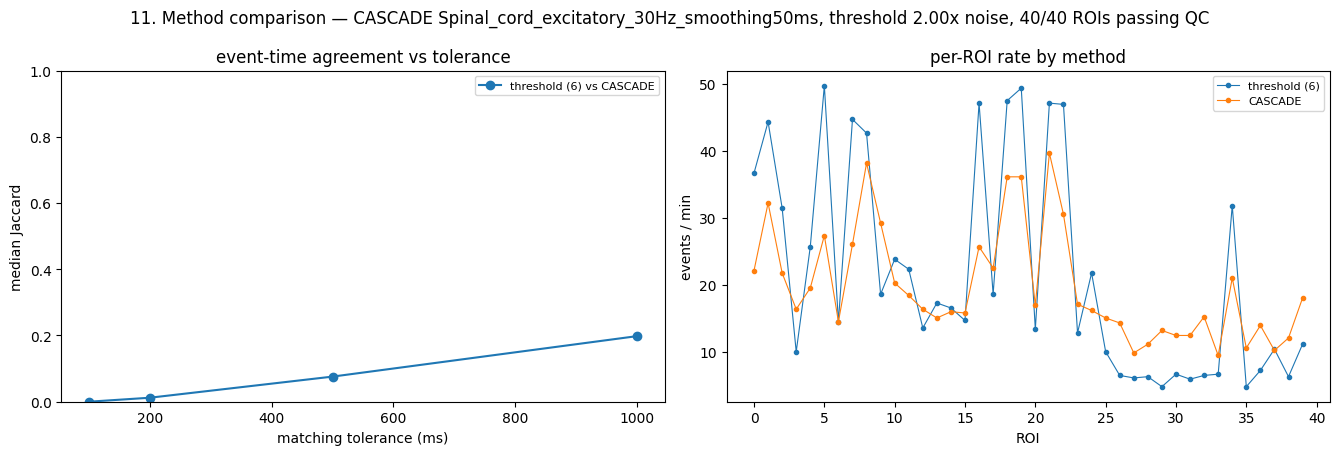

In [178]:
try:
    from oasis.functions import deconvolve as _oasis_deconvolve
    HAVE_OASIS = True
except ImportError:
    HAVE_OASIS = False
    print("! oasis not installed (pip install oasis-deconv in the Cajal env) -- "
          "running CASCADE vs threshold detector only")

METHOD_K = 3.0     # each method's own output is binarised at this x its robust noise


def onsets_from(x, k=METHOD_K):
    """Onsets in any method's output. The deviation from the ROI's own baseline is what gets
    thresholded: CASCADE never returns zero (its floor here is ~0.2 Hz), so thresholding the
    raw value puts the whole recording above threshold and yields one giant 'event'."""
    x = np.asarray(x, dtype=float)
    x = x - np.median(x[np.isfinite(x)])
    return event_runs(x, k * max(noise_mad(x), 1e-12), min_frames=1)[0]


methods = {"threshold (6)": [event_runs(dff_corr[:, j], EVENT_THRESHOLD_K * event_noise[j])[0]
                             for j in range(n_roi)],
           "CASCADE": [onsets_from(np.nan_to_num(spike_rates[j])) for j in range(n_roi)]}
if HAVE_OASIS:
    methods["OASIS"] = [onsets_from(_oasis_deconvolve(dff_cascade[:, j].astype(np.float64),
                                                      penalty=1)[1]) for j in range(n_roi)]


def jaccard(a, b, tol=1):
    if a.size == 0 and b.size == 0:
        return np.nan
    matched = sum(np.any(np.abs(b - x) <= tol) for x in a)
    return matched / (a.size + b.size - matched) if (a.size + b.size - matched) else np.nan


# A single +/-1-bin number cannot distinguish "these methods find different activity" from
# "these methods find the same activity a few hundred ms apart". At 10 Hz that difference is
# the whole question, so report a tolerance ladder.
JACCARD_TOL_FRAMES = [1, 2, 5, 10]
names = list(methods)
pairs = [(names[i], names[j]) for i in range(len(names)) for j in range(i + 1, len(names))]
jac = {p: np.array([jaccard(methods[p[0]][j], methods[p[1]][j]) for j in range(n_roi)])
       for p in pairs}
rates = {m: np.array([len(v) for v in methods[m]]) / dur_min for m in names}
ladder = {p: [np.nanmedian([jaccard(methods[p[0]][j], methods[p[1]][j], tol)
                            for j in range(n_roi)]) for tol in JACCARD_TOL_FRAMES]
          for p in pairs}
for p in pairs:
    rho = spearmanr(rates[p[0]][roi_pass], rates[p[1]][roi_pass]).statistic
    print(f"{p[0]} vs {p[1]}: per-ROI rate rho = {rho:+.2f}; "
          f"events/ROI {np.median(rates[p[0]]) * dur_min:.0f} vs {np.median(rates[p[1]]) * dur_min:.0f}")
    print("  median Jaccard by tolerance: " + ", ".join(
        f"+/-{t} frames ({t * _dt * 1000:.0f} ms) {v:.3f}"
        for t, v in zip(JACCARD_TOL_FRAMES, ladder[p])))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
for p in pairs:
    axes[0].plot([t * _dt * 1000 for t in JACCARD_TOL_FRAMES], ladder[p], "o-",
                 label=f"{p[0]} vs {p[1]}")
axes[0].set_xlabel("matching tolerance (ms)"); axes[0].set_ylabel("median Jaccard")
axes[0].set_ylim(0, 1); axes[0].legend(fontsize=8)
axes[0].set_title("event-time agreement vs tolerance")
for m, c in zip(names, ["tab:blue", "tab:orange", "tab:green"]):
    axes[1].plot(np.arange(n_roi)[roi_pass], rates[m][roi_pass], "o-", ms=3, lw=0.8, label=m, color=c)
axes[1].set_xlabel("ROI"); axes[1].set_ylabel("events / min"); axes[1].legend(fontsize=8)
axes[1].set_title("per-ROI rate by method")
fig.suptitle(f"11. Method comparison — CASCADE {CASCADE_MODEL_NAME}, threshold "
             f"{EVENT_THRESHOLD_K:.2f}x noise, {int(roi_pass.sum())}/{n_roi} ROIs passing QC")
fig.tight_layout(); save_fig(fig, "11_method_comparison"); plt.show()


## 12. Parameter sensitivity — does the conclusion survive the knobs?

The baseline percentile, baseline window and neuropil alpha are all judgement calls with no
ground truth to settle them (CLAUDE.md §6). A result that only exists at one corner of this
grid is a parameter artifact.

Note the notebook default `BASELINE_WINDOW_S = 15` is **shorter than the 30–60 s CLAUDE.md §3
recommends**. A short window with a low percentile tracks the signal instead of the baseline
and absorbs sustained events into F0 — which matters directly for a spontaneous-activity
readout, because it preferentially erases the longest events.

The requirement is not that the numbers stay identical, but that the *conclusion* either
holds across the grid or is explicitly scoped to the range where it holds.


sensitivity grid: 80 combinations on 40 QC-passing ROIs
  operating point: alpha 1.00 (estimated) -> nearest grid alpha 1.0, percentile 10, window 15s
    event_rate_per_min: 4.655 to 41.525 (there: 12.476)
            pct_active: 70.000 to 100.000 (there: 72.500)
              median_r: 0.001 to 0.863 (there: 0.019)


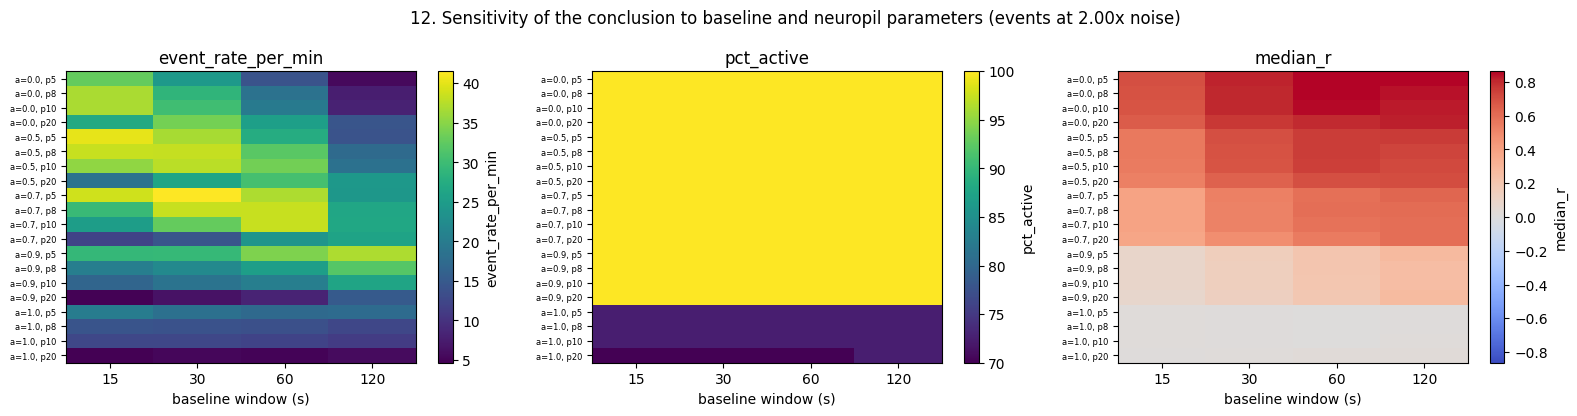

In [179]:
GRID_PCT = [5, 8, 10, 20]
GRID_WIN_S = [15, 30, 60, 120]
GRID_ALPHA = [0.0, 0.5, 0.7, 0.9, 1.0]   # 1.0 = the widefield expectation (see 3f)

_pass = np.flatnonzero(roi_pass)
rows = []
for a in GRID_ALPHA:
    Fa = F_roi - a * F_neuropil
    for pct in GRID_PCT:
        for win_s in GRID_WIN_S:
            win = max(3, round(win_s / _dt))
            d = np.empty((n_frames, _pass.size), dtype=np.float32)
            for c, j in enumerate(_pass):
                f0 = np.clip(percentile_filter(Fa[:, j], pct, size=win, mode="nearest"), 1e-3, None)
                d[:, c] = (Fa[:, j] - f0) / f0
            noise_g = np.array([noise_mad(d[:, c]) for c in range(_pass.size)])
            n_ev = np.array([event_runs(d[:, c], EVENT_THRESHOLD_K * noise_g[c])[0].size
                             for c in range(_pass.size)])
            rows.append({"alpha": a, "percentile": pct, "window_s": win_s,
                         "event_rate_per_min": float(np.median(n_ev / dur_min)),
                         "pct_active": float(100 * np.mean(n_ev > 0)),
                         "median_r": median_offdiag(d[frame_valid])})
sweep = pd.DataFrame(rows)
# With NEUROPIL_ALPHA_MODE="estimated" the operating point is a per-ROI alpha, which is not
# a grid value; quote the nearest grid cell rather than pretending there is an exact match.
_ref_a = min(GRID_ALPHA, key=lambda a: abs(a - float(np.median(alpha_used))))
_ref = sweep.query("alpha == @_ref_a and percentile == @BASELINE_PERCENTILE "
                   "and window_s == @BASELINE_WINDOW_S")
print(f"sensitivity grid: {len(sweep)} combinations on {_pass.size} QC-passing ROIs")
print(f"  operating point: alpha {np.median(alpha_used):.2f} ({NEUROPIL_ALPHA_MODE}) "
      f"-> nearest grid alpha {_ref_a}, percentile {BASELINE_PERCENTILE}, "
      f"window {BASELINE_WINDOW_S}s")
for col in ("event_rate_per_min", "pct_active", "median_r"):
    print(f"  {col:>20}: {sweep[col].min():.3f} to {sweep[col].max():.3f} "
          f"(there: {_ref[col].iat[0]:.3f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, col, cmap in zip(axes, ("event_rate_per_min", "pct_active", "median_r"),
                         ("viridis", "viridis", "coolwarm")):
    piv = sweep.pivot_table(index=["alpha", "percentile"], columns="window_s", values=col)
    kw = dict(vmin=-abs(piv.to_numpy()).max(), vmax=abs(piv.to_numpy()).max()) if cmap == "coolwarm" else {}
    im = ax.imshow(piv.to_numpy(), cmap=cmap, aspect="auto", **kw)
    fig.colorbar(im, ax=ax, label=col)
    ax.set_xticks(range(len(GRID_WIN_S))); ax.set_xticklabels(GRID_WIN_S)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([f"a={a}, p{p}" for a, p in piv.index], fontsize=6)
    ax.set_xlabel("baseline window (s)"); ax.set_title(col)
fig.suptitle(f"12. Sensitivity of the conclusion to baseline and neuropil parameters "
             f"(events at {EVENT_THRESHOLD_K:.2f}x noise)")
fig.tight_layout(); save_fig(fig, "12_parameter_sensitivity"); plt.show()
